# ReCell — used-device pricing

Portfolio revision of a 2023 PGP Supervised Learning (Foundations) project.
UT Austin McCombs / TEE + Great Learning. Certificate — not a UT degree.

## Takeaways

- **normalized_new_price** is the driver of **normalized_used_price** (final slope 0.413; raw r ≈ 0.83).
- Train R² 0.843 / test R² 0.837 on 3,444 devices (10 Infinix rows dropped). Test MAE 0.182; MAPE ≈ 4.3% in normalized units.
- Size enters as log(weight in grams). Battery was dropped after it fought weight (r ≈ 0.81). Screen dropped on VIF; fit barely moved.
- Age: years_running ≈ −0.018 per year. 4G vs no ≈ +0.045. 5G and days_used did not stay in the final line.
- Do not invert these scores to rupees. The file has no raw INR and no published inverse transform.
- Residual tails fail Shapiro; Goldfeld–Quandt p = 0.080 (fail-to-reject equal variance). Coefficients still usable at n_train = 2,410.

### Context

ReCell prices used and refurbished phones and tablets. The question is: which device traits move used price, and whether a linear model is good enough to estimate that price.

### Objective

Build a linear regression for **normalized_used_price** and name the drivers (new-price, spec, age/use). Check residuals. State what the model should **not** be used for.

### Columns used

brand_name, os, screen_size, 4g, 5g, main_camera_mp, selfie_camera_mp, int_memory, ram, battery, weight, release_year, days_used, normalized_new_price, normalized_used_price (target).

## Importing necessary libraries

In [313]:
#C1
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype, is_string_dtype

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 50)

In [314]:
#C2, Set up and document the 'home' directory for this excercise and any artifacts
from pathlib import Path


IN_COLAB = True   # False when the notebook sits in C:\code\... with used_device_data.csv beside it

if IN_COLAB:
    from google.colab import drive
    mount = Path("/content/drive")
    if not (mount.exists() and any(mount.iterdir())):
        drive.mount("/content/drive")
    MyDataFile = Path("/content/drive/MyDrive/Colab Notebooks/used_device_data.csv")
else:
    MyDataFile = Path("used_device_data.csv")

if not MyDataFile.exists():
    raise FileNotFoundError(MyDataFile)

print("Loading", MyDataFile)
df = pd.read_csv(MyDataFile)

#we will be modifing the df... create a roll back copy
df_backup= df.copy()


Loading /content/drive/MyDrive/Colab Notebooks/used_device_data.csv


In [315]:
#C3, view the df
print(df.shape)


(3454, 15)


In [316]:
#C4,  df information
df.info()
print(df.isnull().sum().sort_values(ascending=False))
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3454 entries, 0 to 3453
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand_name             3454 non-null   object 
 1   os                     3454 non-null   object 
 2   screen_size            3454 non-null   float64
 3   4g                     3454 non-null   object 
 4   5g                     3454 non-null   object 
 5   main_camera_mp         3275 non-null   float64
 6   selfie_camera_mp       3452 non-null   float64
 7   int_memory             3450 non-null   float64
 8   ram                    3450 non-null   float64
 9   battery                3448 non-null   float64
 10  weight                 3447 non-null   float64
 11  release_year           3454 non-null   int64  
 12  days_used              3454 non-null   int64  
 13  normalized_used_price  3454 non-null   float64
 14  normalized_new_price   3454 non-null   float64
dtypes: f

In [317]:
#C4, duplicates
print(df.duplicated().sum())

0


## Progress Summary A : Missing values

- No missing used or new prices.
- 179 phones have no rear-camera MP. That is the only large gap.
- A few rows miss weight, battery, RAM, storage, or selfie MP.
- Do not drop 179 rows without checking whether those brands/years are different.

## Function Definitions
An area to define functions for code reuse

###Missing Values

In [318]:
#C4.5

def missing_values(df_ref, categorical, numerical):
  print('*** categorical is:',categorical, '\n*** numerical is: ', numerical)
  df_tmp = df_ref[[categorical,numerical]]
  df_tmp = df_tmp[df_tmp[numerical].isnull()]
  df_tmp=df_tmp[categorical].value_counts()
  df_tmp= df_tmp.reset_index()
  df_tmp.columns = [categorical,'missing_' + numerical]


  # create a pivot with max min mean median
  df_tmp2 = pd.pivot_table(df_ref
                            , values=numerical
                            , index=[categorical]
                            , margins = False
                            , margins_name="____ "
                            , aggfunc=["min", "max", "mean","median", "std"]
                            , dropna=False)

  #merge the headers... make the df 2 dimentional
  df_tmp2.columns = df_tmp2.columns.map(lambda x: f'{x[0]}_{x[1]}')

  # #a data frame of all counts
  df_tmp3 = df[categorical].value_counts()
  df_tmp3 = df_tmp3.reset_index()
  df_tmp3.columns=[categorical, numerical]

  # # merge 1 of 2
  df_tmp4 = pd.merge(df_tmp3, df_tmp2, on=categorical)
  # merge 2 of 2... all the data in on df
  df_tmp4 = pd.merge(df_tmp4, df_tmp, on=categorical)

  # # calculate missing records percent
  df_tmp4["missing_percent"] = ( df_tmp4['missing_' + numerical] / df_tmp4[  numerical] )
  #sort
  df_tmp4=df_tmp4.sort_values(by=['missing_percent'], ascending=False)
  #format the %
  df_tmp4['missing_percent'] = df_tmp4['missing_percent'].apply('{:.2%}'.format)


  return (df_tmp4)

In [319]:
#C4.7

def NB_TOC(FPFN):
    import json
    from pathlib import Path

    NB = Path(FPFN)
    nb = json.loads(NB.read_text(encoding="utf-8"))

    for i, cell in enumerate(nb["cells"]):
        if cell.get("cell_type") != "markdown":
            continue
        lines = [ln.rstrip() for ln in "".join(cell.get("source", [])).splitlines()]
        lines = [ln for ln in lines if ln.strip()]
        if not lines:
            continue
        first = lines[0].strip()
        if first.startswith("#"):
            hashes = len(first) - len(first.lstrip("#"))
            title = first[hashes:].strip()
            print(f"{i:03d}  {'#' * hashes}{'  ' * max(hashes - 1, 0)}{title}")
        else:
            print(f"{i:03d}  (p) {first[:100]}")



In [320]:
#C4.8
print(NB_TOC("/content/drive/My Drive/Colab Notebooks/ReCell Portfolio.ipynb"))

000  #ReCell — used-device pricing
001  ##  Importing necessary libraries
007  ##  Progress Summary A : Missing values
008  ##  Function Definitions
009  ###    Missing Values
014  ###    histogram_boxplot
017  ###    labeled_barplot
020  ###    category_boxplot
023  ###    treat_outliers
025  ###    adj_r2_score - mape_score - model_performance_regression
027  ###    Variance Inflation Factor (VIF)
029  ###    treating_multicollinearity
031  ##  Data Overview
032  (p) - Observations
039  ##  Exploratory Data Analysis (EDA)
040  ###    UNIVARIATE ANALYSIS:
041  ####      **brand_name**  Name of manufacturing brand
043  ####      **os** OS on which the device runs
045  ####      **screen_size** Size of the screen in cm
047  ####      **4g**  Whether 4G is available or not
049  ####      **5g**  Whether 5G is available or not
051  ####      **main_camera_mp**  Resolution of the rear camera in megapixels
056  ####      **selfie_camera_mp**  Resolution of the front camera in megapixels
060

In [321]:
#C5 Glimpse
# The function glimpse takes a dataframe as a parameter and prints the shape and top, head and random rows

def glimpse(df):
    print('glimpse shape...')
    print(f"{df.shape[0]} rows and {df.shape[1]} columns")
    print('glimpse head...')
    display(df.head(5))
    print('glimpse sample...')
    display(df.sample(5, replace=True))
    print('glimpse tail...')
    display(df.tail(5))

###histogram_boxplot
The histogram_boxplot() function can be used to draw a histogram and a boxplot of a variable on thesame scale. The function takes as input a dataframe, the variable to be plotted, the size of the figure(set to 15x10 by default), whether or not to display the density curve on the histogram (set to falseby default), and the number of bins of the histogram (set to be automatically determined by seabornby default)

In [322]:
#C6
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined
    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram
    plt.show()
    print ('***********************')
    print(data[feature].describe())

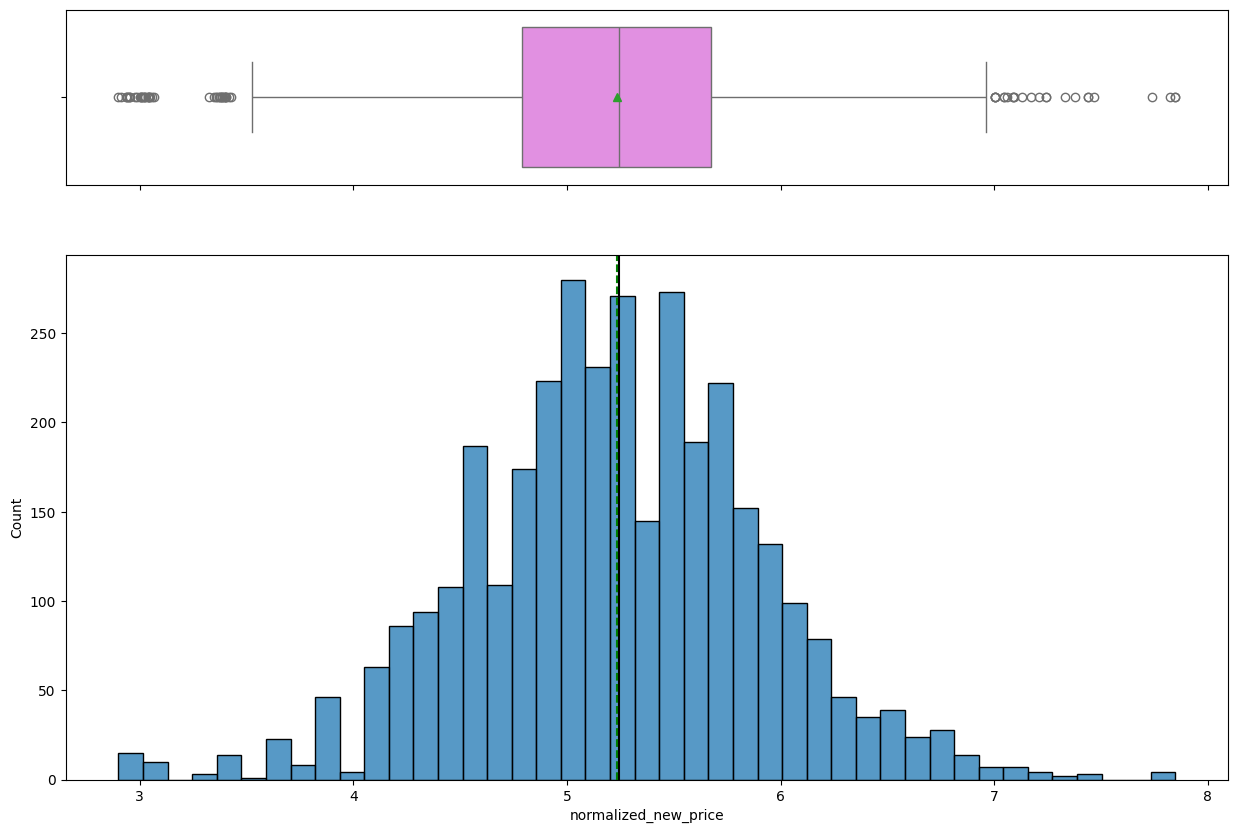

***********************
count    3454.000000
mean        5.233107
std         0.683637
min         2.901422
25%         4.790342
50%         5.245892
75%         5.673718
max         7.847841
Name: normalized_new_price, dtype: float64


In [323]:
#C7 test call to histogram_boxplot
histogram_boxplot( df, "normalized_new_price")

###labeled_barplot
The labeled_barplot() function can be used to display a bar graph with labels (count or percentage) above each of the bars. It takes as input a dataframe, the variable to be plotted, whether to display the count of percentages over the bars (set to counts by default) and the top n number of most frequent categories to display (set to all categories by default). The different blocks in the function work as follows:

In [324]:
#C8
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top
    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """
    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))
    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )
    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category
        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot
        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage
    plt.show()  # show the plot

    counts = data[feature].value_counts()
    percs = data[feature].value_counts(normalize=True).mul(100).round(1).astype(str) + '%'
    tmp_df=pd.concat([counts,percs], axis=1, keys=['count', 'percentage'])
    print(tmp_df)

/tmp/ipykernel_1420/372482018.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


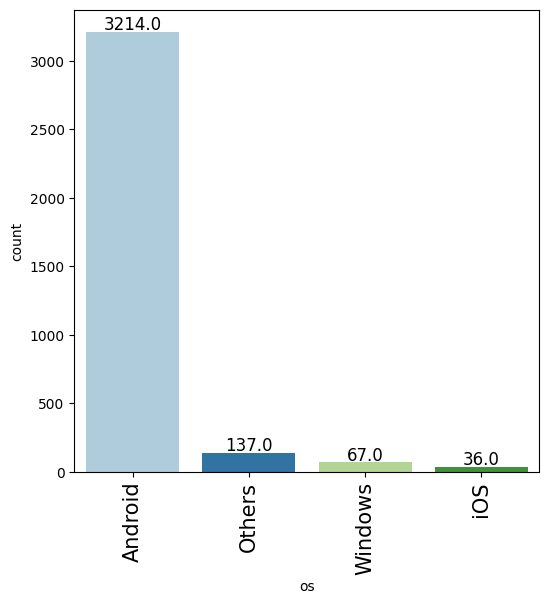

         count percentage
os                       
Android   3214      93.1%
Others     137       4.0%
Windows     67       1.9%
iOS         36       1.0%


In [325]:
#C9 test call to labeled_barplot
labeled_barplot( df, "os")

### category_boxplot





In [326]:
#C10
def category_boxplot(df_tmp, cat, num, hhue="empty", wider=0, taller=0) :
    """
    A categorical boxplot
    df_tmp is the dataset
    num is your numeric
    cat is you catgorical
    hhue is defaulted to empay and allows a categorical set for the hue parameter
    wider allows making the image wider than default
    taller allows makeing image taller h
    """
    if hhue == "empty" :
      print("**********\n* Comparing ", cat, " to ", num, "- \n**********")
      plt.figure(figsize=(15+wider, 9+taller))
      ax=sns.boxplot(data=df, x=cat, y=num)
      plt.setp(ax.get_xticklabels(), rotation=45)
      plt.show()
    else:
      print("**********\n* Comparing ", cat, " to ", num, " accross " , hhue, "\n**********")
      plt.figure(figsize=(15+wider, 9+taller))
      ax=sns.boxplot(data=df, x=cat, y=num, hue=hhue)
      plt.setp(ax.get_xticklabels(), rotation=45)
      plt.show()




**********
* Comparing  os  to  battery - 
**********


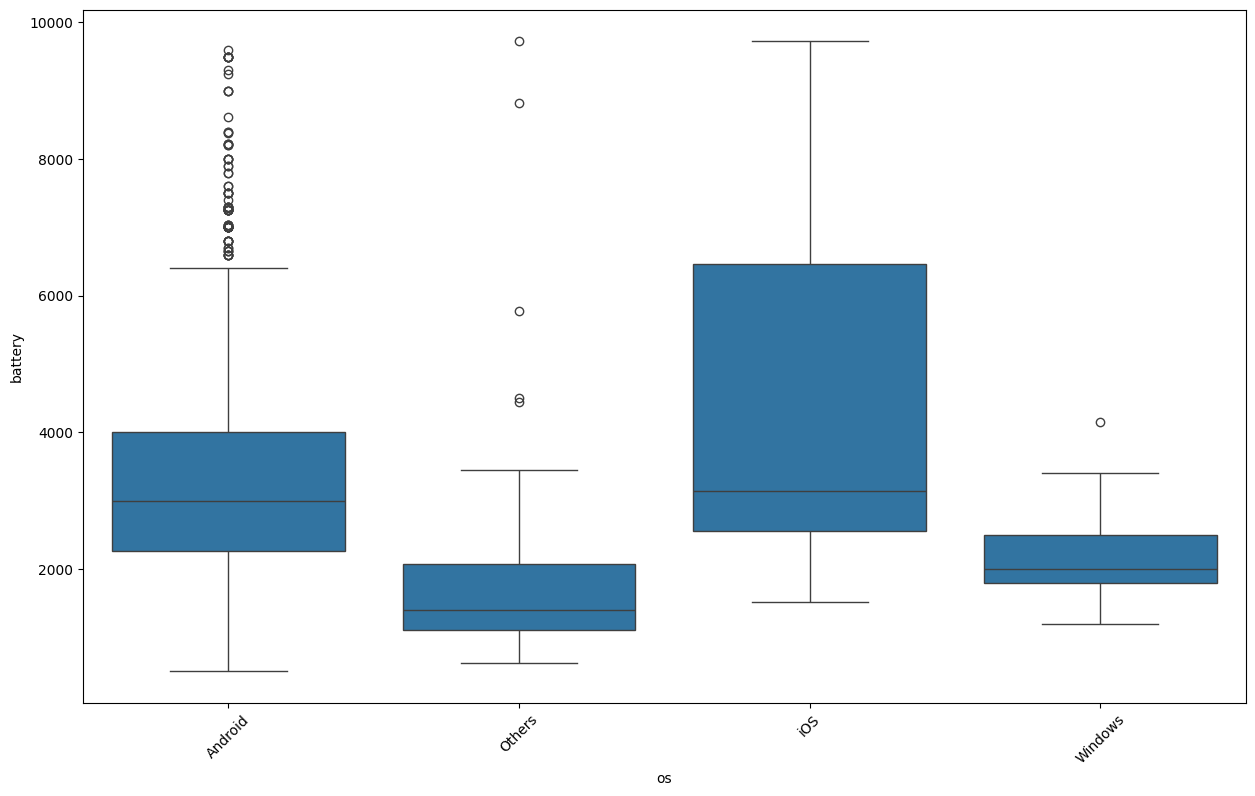

In [327]:
#C11
category_boxplot(df,"os","battery" )

###treat_outliers



In [328]:
#C10
# Treating outliers
# We will cap/clip the minimum and maximum value of these columns to the lower and upper whisker value of the boxplot found
# using Q1 - 1.5*IQR and Q3 + 1.5*IQR, respectively.
# Note: Generally, a value of 1.5 * IQR is taken to cap the values of outliers to upper and lower whiskers but any number (example 0.5, 2, 3, etc)
# other than 1.5 can be chosen. The value depends upon the business problem statement.

def treat_outliers(df, col):
    """
    treats outliers in a variable
    col: str, name of the numerical variable
    df: dataframe
    col: name of the column
    """
    Q1 = df[col].quantile(0.25)  # 25th quantile
    Q3 = df[col].quantile(0.75)  # 75th quantile
    IQR = Q3 - Q1                # Inter Quantile Range (75th perentile - 25th percentile)
    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR

    # all the values smaller than lower_whisker will be assigned the value of lower_whisker
    # all the values greater than upper_whisker will be assigned the value of upper_whisker
    # the assignment will be done by using the clip function of NumPy
    df[col] = np.clip(df[col], lower_whisker, upper_whisker)

    return df

###adj_r2_score - mape_score - model_performance_regression
### Regression metrics helpers

Used after a model exists. sklearn supplies R², MAE, RMSE. `adj_r2_score` and `mape_score` are local. MAPE is unstable if any actual price is 0.

In [329]:
#C11
def adj_r2_score(predictors, targets, predictions):
# function to compute adjusted R-squared
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))

# function to compute MAPE
def mape_score(targets, predictions):
    return np.mean(np.abs(targets - predictions) / targets) * 100

# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mape_score(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf


### Variance Inflation Factor (VIF)

VIF says how much a coefficient’s variance is inflated by correlation with other predictors.

 ~1: little inflation.

 Often inspect above 5 and worry above 10.

 The model’s purpose sets the cutoff, not a law.

In [330]:
#C12

def checking_vif(predictors):
#Let's define a function to check VIF.
    vif = pd.DataFrame()
    vif["feature"] = predictors.columns

    # calculating VIF for each feature
    vif["VIF"] = [
        variance_inflation_factor(predictors.values, i)
        for i in range(len(predictors.columns))
    ]
    return vif


###treating_multicollinearity

Drop-one VIF test after the first model. Do not run in EDA.

Run only after VIF names a short list of columns.
str.startswith(cols) drops every column that begins with that name (useful for dummy groups, easy to over-drop). We will check the list before calling.

In [331]:
#C13
def treating_multicollinearity(predictors, target, high_vif_columns):
    """
    Checking the effect of dropping the columns showing high multicollinearity
    on model performance (adj. R-squared and RMSE)

    predictors: independent variables
    target: dependent variable
    high_vif_columns: columns having high VIF
    """
    # empty lists to store adj. R-squared and RMSE values
    adj_r2 = []
    rmse = []

    # build ols models by dropping one of the high VIF columns at a time
    # store the adjusted R-squared and RMSE in the lists defined previously
    for cols in high_vif_columns:
        # defining the new train set
        train = predictors.loc[:, ~predictors.columns.str.startswith(cols)]

        # create the model
        olsmodel = sm.OLS(target, train).fit()

        # adding adj. R-squared and RMSE to the lists
        adj_r2.append(olsmodel.rsquared_adj)
        rmse.append(np.sqrt(olsmodel.mse_resid))

    # creating a dataframe for the results
    temp = pd.DataFrame(
        {
            "col": high_vif_columns,
            "Adj. R-squared after_dropping col": adj_r2,
            "RMSE after dropping col": rmse,
        }
    ).sort_values(by="Adj. R-squared after_dropping col", ascending=False)
    temp.reset_index(drop=True, inplace=True)

    return temp

## Data Overview

- Observations
  * There are 15 Columns
  * There are 3454 records
  * SIX columns have missing values
  
   selfie_camera_mp 2
  
   int_memory 4  
  
   ram 4
  
   battery 6  
  
   weight 7
  
   main_camera_mp  has **179 missing value**s... by far the largest
 * cast **release_year** to an object
 * There are TWO yes/no fields (4g and 5g)
- Sanity checks


1.   1-(179/3454) = 94.82% : The worst completeness is 94.8% on rear camera.
2.   Column **os** contains 4 values. Android dominates this file (~93%).
3.   Collected 2021; last model year 2020.

In [332]:
#C14 check for duplicates
df.duplicated().sum()

np.int64(0)

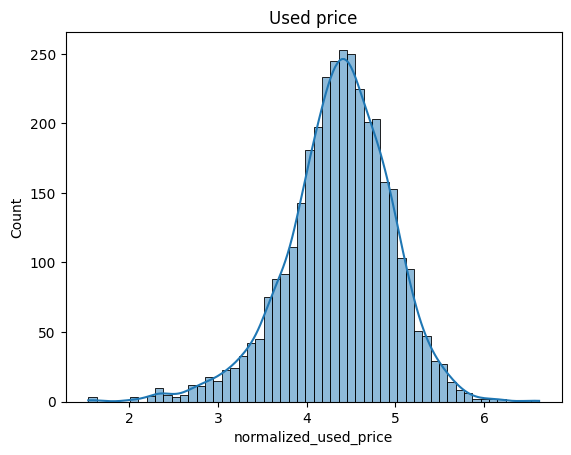

,normalized_used_price
count,3454.000000
mean,4.364712
std,0.588914
min,1.536867
25%,4.033931
50%,4.405133
75%,4.755700
max,6.619433


In [333]:
#C15
sns.histplot(df["normalized_used_price"], kde=True)
plt.title("Used price")
plt.show()
df["normalized_used_price"].describe()

In [334]:
#C16 Check for missing values in the data
df_tmp = df.isnull().sum().reset_index(name ='MissingCount')
df_tmp[df_tmp['MissingCount'] > 0]

,index,MissingCount
5,main_camera_mp,179
6,selfie_camera_mp,2
7,int_memory,4
8,ram,4
9,battery,6
10,weight,7


In [335]:
#C17
#print out value counts for object columns
df_tmp = df[['brand_name','os','4g','5g', 'release_year']]
i=0
for col in df_tmp.columns:
    i=i+1
    print('*******', 'Value infomation on column:', col, '\n')
    print('There are', df_tmp[col]. nunique(), 'values in ' , col, 'they are\n', df_tmp[col].unique())
    print('\nThe counts for',col, 'follows\n','\n')
    print( df_tmp[col].value_counts(sort=True, ascending=False, dropna=True))
    print('Total count is:', df_tmp[col].count(), '\n\n\n')

******* Value infomation on column: brand_name 

There are 34 values in  brand_name they are
 ['Honor' 'Others' 'HTC' 'Huawei' 'Infinix' 'Lava' 'Lenovo' 'LG' 'Meizu'
 'Micromax' 'Motorola' 'Nokia' 'OnePlus' 'Oppo' 'Realme' 'Samsung' 'Vivo'
 'Xiaomi' 'ZTE' 'Apple' 'Asus' 'Coolpad' 'Acer' 'Alcatel' 'BlackBerry'
 'Celkon' 'Gionee' 'Google' 'Karbonn' 'Microsoft' 'Panasonic' 'Sony'
 'Spice' 'XOLO']

The counts for brand_name follows
 

brand_name
Others        502
Samsung       341
Huawei        251
LG            201
Lenovo        171
ZTE           140
Xiaomi        132
Oppo          129
Asus          122
Alcatel       121
Micromax      117
Vivo          117
Honor         116
HTC           110
Nokia         106
Motorola      106
Sony           86
Meizu          62
Gionee         56
Acer           51
XOLO           49
Panasonic      47
Realme         41
Apple          39
Lava           36
Celkon         33
Spice          30
Karbonn        29
BlackBerry     22
OnePlus        22
Microsoft     

In [336]:
#C18
# Who is broken(brands that have missing cameras)
# Check the empty values accross the object values
df_tmp = df[['brand_name','main_camera_mp']]
df_tmp = df_tmp[df_tmp['main_camera_mp'].isnull()]
df_tmp=df_tmp['brand_name'].value_counts()
df_tmp= df_tmp.reset_index()
df_tmp.columns = ['brand_name','missing_main_camera_mp']
df_tmp

# create a pivot with max min mean median
df_tmp2 = pd.pivot_table(df
                          , values='main_camera_mp'
                          , index=['brand_name']
                          , margins = False
                          , margins_name="____ "
                          ,aggfunc=["min", "max", "mean","median", np.std]
                          ,dropna=False
                         ,fill_value=0)

#merge the headers... make the df 2 dimentional
df_tmp2.columns = df_tmp2.columns.map(lambda x: f'{x[0]}_{x[1]}')

#a data frame of all counts
df_tmp3 = df['brand_name'].value_counts()
df_tmp3 = df_tmp3.reset_index()
df_tmp3.columns=['brand_name', 'brand_count']

# merge 1 of 2
df_tmp4 = pd.merge(df_tmp3, df_tmp2, on='brand_name')
# merge 2 of 2... all the data in on df
df_tmp4 = pd.merge(df_tmp4, df_tmp, on='brand_name')

# calculate missing records percent
df_tmp4["missing_percent"] = ( df_tmp4["missing_main_camera_mp"] / df_tmp4["brand_count"] )
df_tmp4['missing_percent'] = df_tmp4['missing_percent'].apply('{:.2%}'.format)

#print the data set... use this code as the basis for a function to produce missing value data.
df_tmp4


/tmp/ipykernel_1420/3701587205.py:12: FutureWarning: The provided callable <function std at 0x7a4a9657c0e0> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  df_tmp2 = pd.pivot_table(df


,brand_name,brand_count,min_main_camera_mp,max_main_camera_mp,mean_main_camera_mp,median_main_camera_mp,std_main_camera_mp,missing_main_camera_mp,missing_percent
0,ZTE,140,2.00,48.0,11.695588,13.0,6.061223,4,2.86%
1,Xiaomi,132,8.00,22.5,12.399083,13.0,1.860630,23,17.42%
2,Oppo,129,3.15,16.0,10.444495,13.0,3.277634,20,15.50%
3,Asus,122,1.00,23.0,10.018220,13.0,4.564714,4,3.28%
4,Vivo,117,5.00,16.0,12.859223,13.0,2.020019,14,11.97%
5,Motorola,106,5.00,48.0,12.920455,13.0,6.789481,18,16.98%
6,Sony,86,3.15,23.0,14.870886,13.0,6.631837,7,8.14%
7,Meizu,62,8.00,21.0,13.608511,13.0,2.808050,15,24.19%
8,Panasonic,47,3.15,20.1,10.427778,8.0,3.486004,2,4.26%
9,Realme,41,13.00,13.0,13.000000,13.0,0.000000,36,87.80%


In [337]:
# C19
# Statistical summary of the dataset
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.0,NaN,NaN,NaN,13.713115,3.80528,5.08,12.7,12.83,15.34,30.71
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.0,NaN,NaN,NaN,9.460208,4.815461,0.08,5.0,8.0,13.0,48.0
selfie_camera_mp,3452.0,NaN,NaN,NaN,6.554229,6.970372,0.0,2.0,5.0,8.0,32.0
int_memory,3450.0,NaN,NaN,NaN,54.573099,84.972371,0.01,16.0,32.0,64.0,1024.0
ram,3450.0,NaN,NaN,NaN,4.036122,1.365105,0.02,4.0,4.0,4.0,12.0
battery,3448.0,NaN,NaN,NaN,3133.402697,1299.682844,500.0,2100.0,3000.0,4000.0,9720.0


## Exploratory Data Analysis (EDA)

###UNIVARIATE ANALYSIS:

Summary findings

| Column | Role in the model | What univariate showed |
| --- | --- | --- |
| normalized_used_price | Target | Tight; mean ≈ median ≈ 4.36; std 0.59 |
| normalized_new_price | Strong candidate | Same shape, higher (mean 5.23). Used sits below new. |
| brand_name | Dummy / group | 34 levels; Others is 14.5% (catch-all). |
| os | Dummy | Android 93%; iOS 1% — iOS slope will be shaky. |
| 4g, 5g | Dummies | 4G 68%; 5G 4.4%. |
| release_year | Numeric or dummy | 2013–2015 ≈ 50% of rows; 2020 is 8%. |
| days_used | Wear | About 91–1094 days; median ~691. |
| main_camera_mp | Spec | Median 8 MP; 179 missing, all Android; Realme / Infinix / OnePlus badly incomplete. |
| selfie_camera_mp | Spec | 2 missing (Google). |
| ram | Spec | Almost always 4 GB — weak predictor. |
| int_memory | Spec | Skewed; tail at 1024 GB. |
| screen_size, battery, weight | Size cluster | Move together. Tablets: screen 30.7 cm, battery 9720 mAh, weight 855 g. Future VIF, not a clip list. |




#### **brand_name**  Name of manufacturing brand
Observations :
* OTHERS is the Largest 'brand_name at 505 / 14.5%
* There are 34 values in brand name... a lot... chart clutter
* There are no blanks
* The top three brands are Samsung, Huawei and LG


/tmp/ipykernel_1420/372482018.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


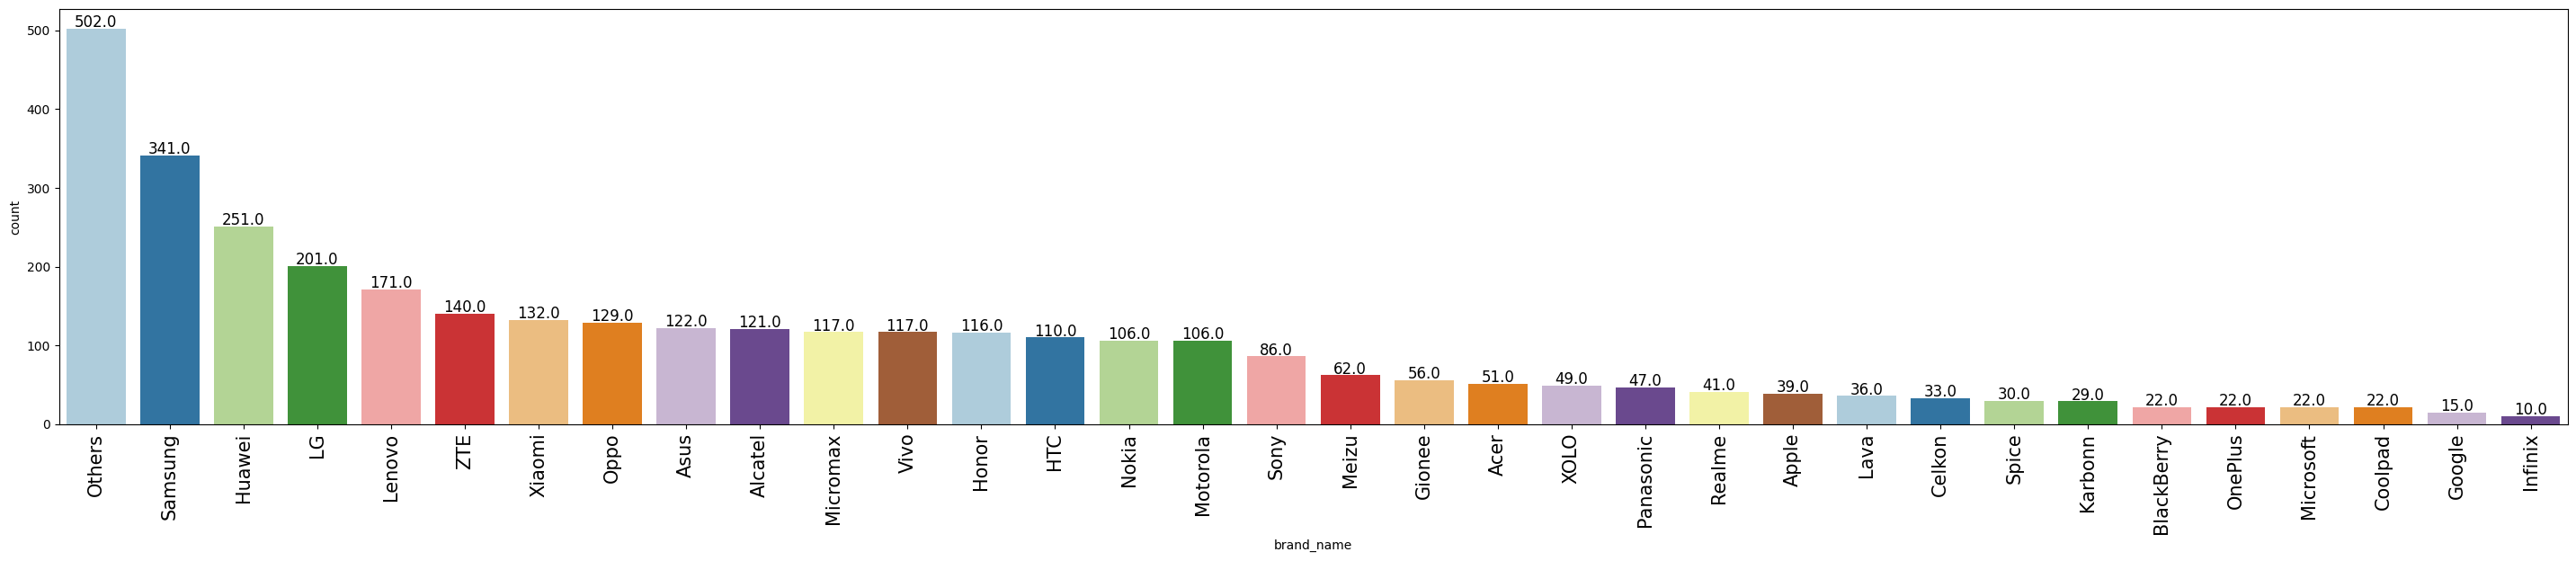

            count percentage
brand_name                  
Others        502      14.5%
Samsung       341       9.9%
Huawei        251       7.3%
LG            201       5.8%
Lenovo        171       5.0%
ZTE           140       4.1%
Xiaomi        132       3.8%
Oppo          129       3.7%
Asus          122       3.5%
Alcatel       121       3.5%
Micromax      117       3.4%
Vivo          117       3.4%
Honor         116       3.4%
HTC           110       3.2%
Nokia         106       3.1%
Motorola      106       3.1%
Sony           86       2.5%
Meizu          62       1.8%
Gionee         56       1.6%
Acer           51       1.5%
XOLO           49       1.4%
Panasonic      47       1.4%
Realme         41       1.2%
Apple          39       1.1%
Lava           36       1.0%
Celkon         33       1.0%
Spice          30       0.9%
Karbonn        29       0.8%
BlackBerry     22       0.6%
OnePlus        22       0.6%
Microsoft      22       0.6%
Coolpad        22       0.6%
Google        

In [338]:
#C20
col ="brand_name"
labeled_barplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

#### **os** OS on which the device runs
Observations
* Andriod is by far the largest percentage of of operations systems (os)
* There are no blanks / empty values

/tmp/ipykernel_1420/372482018.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


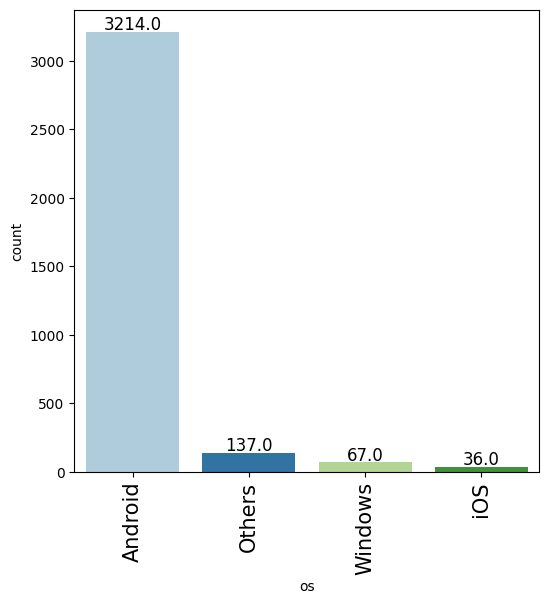

         count percentage
os                       
Android   3214      93.1%
Others     137       4.0%
Windows     67       1.9%
iOS         36       1.0%
There are 3454 total values in  os


In [339]:
#C21
# simple analysis of object ( categorical ) values
col ="os"
labeled_barplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

#### **screen_size** Size of the screen in cm
measured in cm
Observations
* 3454 values ... no missing values
* Outliers... Some vary large screens and some very small screens
* Distribution is normal with a slight skew right
* Q1 is very close to Q2\


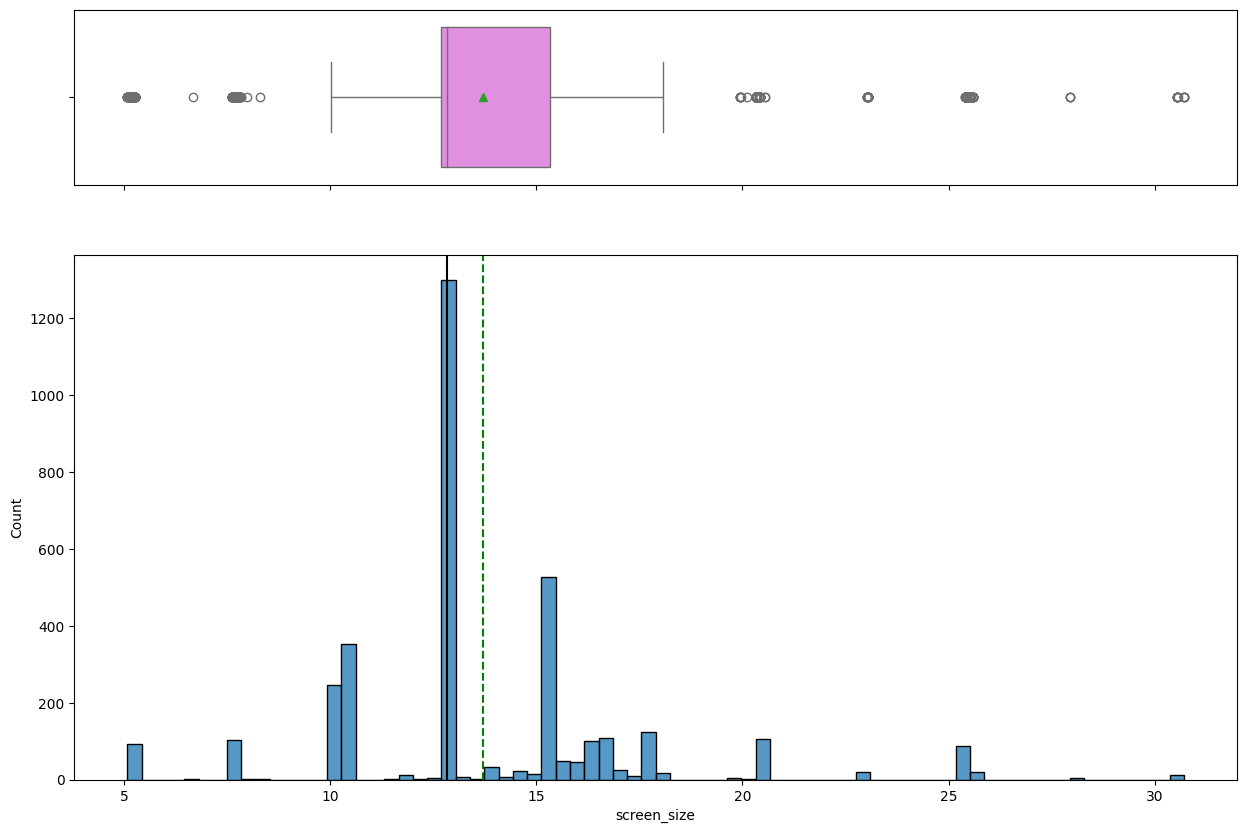

***********************
count    3454.000000
mean       13.713115
std         3.805280
min         5.080000
25%        12.700000
50%        12.830000
75%        15.340000
max        30.710000
Name: screen_size, dtype: float64
There are 3454 total values in  screen_size


In [340]:
#c21
#simple analysis of numeric ( int64 / float 64 ) values
col ="screen_size"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

#### **4g**  Whether 4G is available or not
Observations
* 67.6% of the devices are 4g
* There are no blanks

/tmp/ipykernel_1420/372482018.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


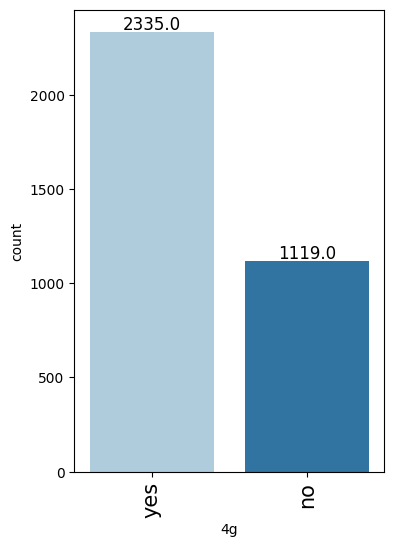

     count percentage
4g                   
yes   2335      67.6%
no    1119      32.4%
There are 3454 total values in  4g


In [341]:
#c22
#simple analysis of object ( categorical ) values
col ="4g"
labeled_barplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

#### **5g**  Whether 5G is available or not
Observations
* 4.4% of the devices are 5g
* There are no missing values
* the total percentage of 4g + 5g is 70.0% leaving 30.0% not 4g or 5g
* Note : 2G and 3G sunset dates are planned

/tmp/ipykernel_1420/372482018.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


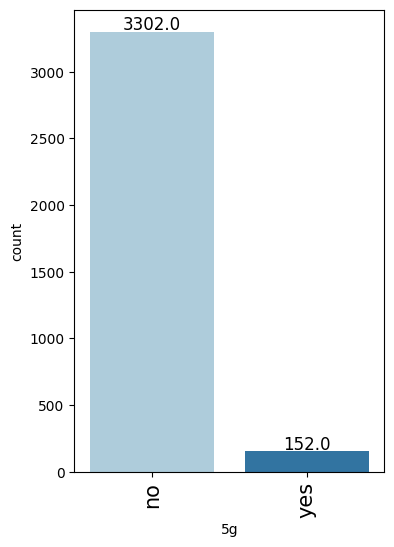

     count percentage
5g                   
no    3302      95.6%
yes    152       4.4%
There are 3454 total values in  5g


In [342]:
#c23
#simple analysis of object ( categorical ) values
col ="5g"
labeled_barplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

#### **main_camera_mp**  Resolution of the rear camera in megapixels
Observations
* we have 179 missing values or 5.7%, All missing valeus are os android and cover 15 of the 34 brands
* distro is normal with slight right skew
* there are two extreme outliers with > 40 Mega Pixel Cameras
* expect a direct corellation between price (new and old) and main_camera_mp


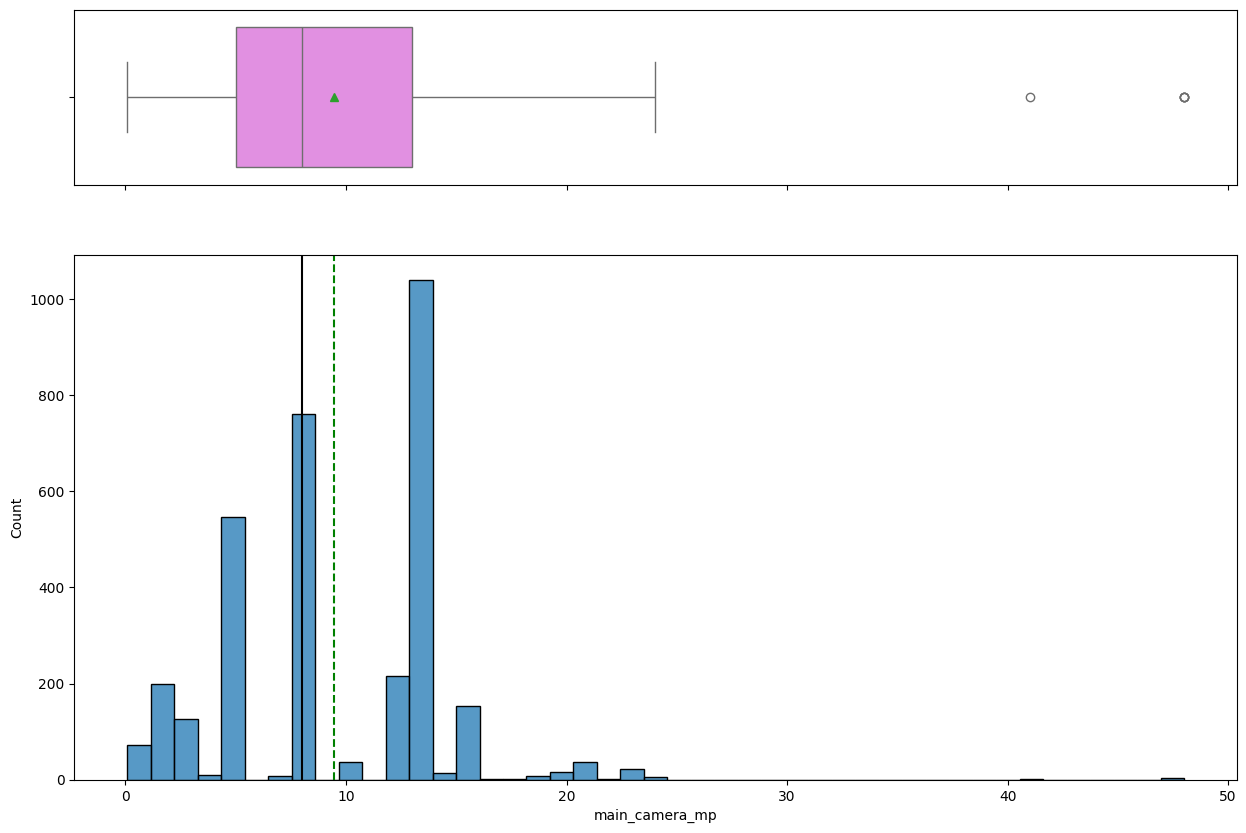

***********************
count    3275.000000
mean        9.460208
std         4.815461
min         0.080000
25%         5.000000
50%         8.000000
75%        13.000000
max        48.000000
Name: main_camera_mp, dtype: float64
There are 3275 total values in  main_camera_mp


In [343]:
#c24
#simple analysis of numeric ( int64 / float 64 ) values
col ="main_camera_mp"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

In [344]:
#c25
#peak at the empty records for main_camera_mp
df[df["main_camera_mp"].isnull()]

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,release_year,days_used,normalized_used_price,normalized_new_price
59,Infinix,Android,17.32,yes,no,NaN,8.0,32.0,2.0,6000.0,209.0,2020,245,4.282068,4.597642
60,Infinix,Android,15.39,yes,no,NaN,8.0,64.0,4.0,5000.0,185.0,2020,173,4.363608,4.711780
61,Infinix,Android,15.39,yes,no,NaN,8.0,32.0,2.0,5000.0,185.0,2020,256,4.181439,4.505460
62,Infinix,Android,15.39,yes,no,NaN,16.0,32.0,3.0,4000.0,178.0,2019,316,4.555244,4.602166
63,Infinix,Android,15.29,yes,no,NaN,16.0,32.0,2.0,4000.0,165.0,2019,468,4.416670,4.871297
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3411,Realme,Android,15.34,yes,no,NaN,16.0,64.0,4.0,4000.0,183.0,2019,503,4.570475,5.159974
3412,Realme,Android,15.32,yes,no,NaN,16.0,64.0,4.0,4035.0,184.0,2019,433,4.521027,5.074424
3413,Realme,Android,15.32,yes,no,NaN,25.0,64.0,4.0,4045.0,172.0,2019,288,4.778199,4.966753
3448,Asus,Android,16.74,yes,no,NaN,24.0,128.0,8.0,6000.0,240.0,2019,325,5.715316,7.059317


In [345]:
#c26
#look at missing main_camera_mp accross os
missing_values(df, "os","main_camera_mp")

*** categorical is: os 
*** numerical is:  main_camera_mp


,os,main_camera_mp,min_main_camera_mp,max_main_camera_mp,mean_main_camera_mp,median_main_camera_mp,std_main_camera_mp,missing_main_camera_mp,missing_percent
0,Android,3214,0.3,48.0,9.767529,8.1,4.644833,179,5.57%


In [346]:
#C27
#look at missing main_camera_mp accross brand_name
missing_values(df, "brand_name","main_camera_mp")

*** categorical is: brand_name 
*** numerical is:  main_camera_mp


,brand_name,main_camera_mp,min_main_camera_mp,max_main_camera_mp,mean_main_camera_mp,median_main_camera_mp,std_main_camera_mp,missing_main_camera_mp,missing_percent
14,Infinix,10,NaN,NaN,NaN,NaN,NaN,10,100.00%
9,Realme,41,13.00,13.0,13.000000,13.0,0.000000,36,87.80%
12,OnePlus,22,13.00,16.0,14.200000,13.0,1.643168,17,77.27%
7,Meizu,62,8.00,21.0,13.608511,13.0,2.808050,15,24.19%
11,BlackBerry,22,5.00,21.0,10.333333,8.0,4.405878,4,18.18%
1,Xiaomi,132,8.00,22.5,12.399083,13.0,1.860630,23,17.42%
5,Motorola,106,5.00,48.0,12.920455,13.0,6.789481,18,16.98%
2,Oppo,129,3.15,16.0,10.444495,13.0,3.277634,20,15.50%
13,Coolpad,22,8.00,16.0,11.263158,13.0,2.663375,3,13.64%
4,Vivo,117,5.00,16.0,12.859223,13.0,2.020019,14,11.97%


#### **selfie_camera_mp**  Resolution of the front camera in megapixels
Observations
* Two missing values both os andriod and brand google
* Normal right skew distro
* outliers beyond the maximum whisker

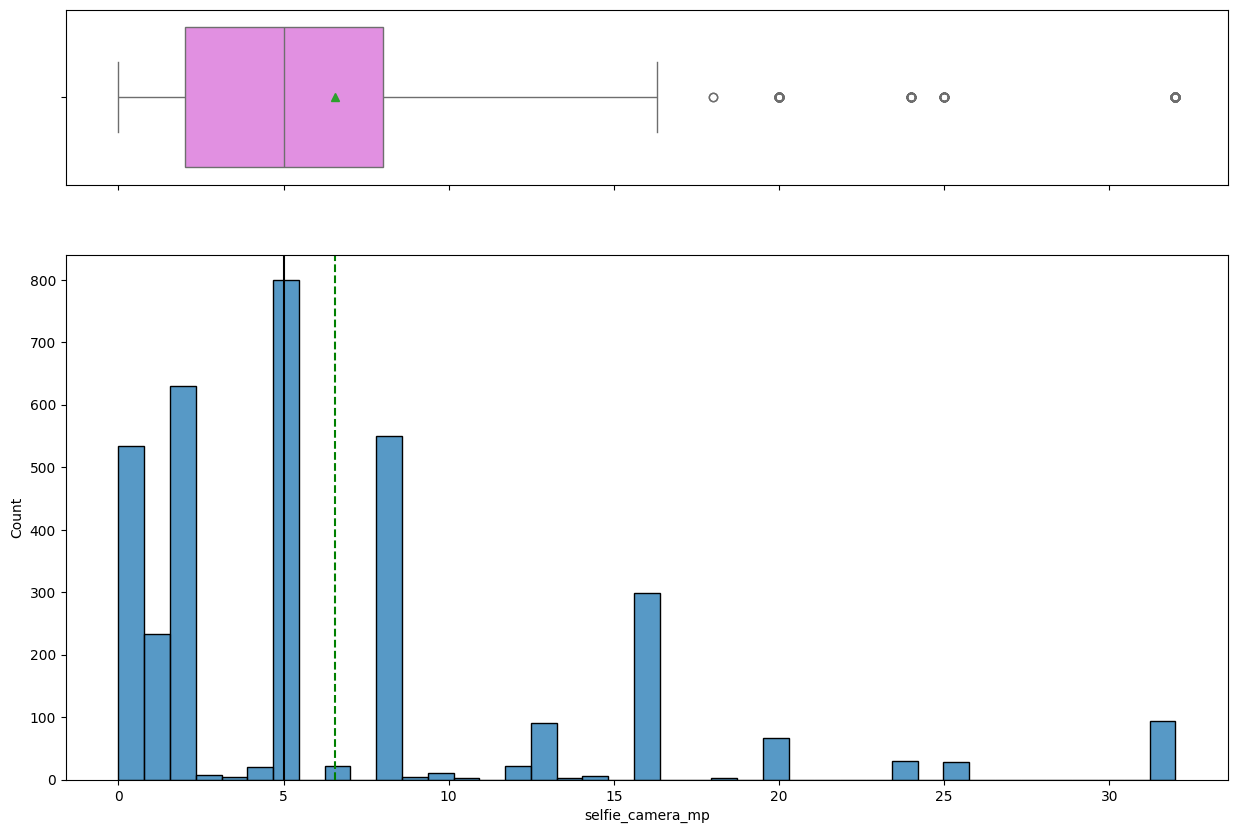

***********************
count    3452.000000
mean        6.554229
std         6.970372
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        32.000000
Name: selfie_camera_mp, dtype: float64
There are 3452 total values in  selfie_camera_mp


In [347]:
#c28
#simple analysis of numeric ( int64 / float 64 ) values
col ="selfie_camera_mp"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

In [348]:
#C29
#look at missing selfie_camera_mp accross os
cat="os"
num="selfie_camera_mp"
missing_values(df, cat,num)

*** categorical is: os 
*** numerical is:  selfie_camera_mp


,os,selfie_camera_mp,min_selfie_camera_mp,max_selfie_camera_mp,mean_selfie_camera_mp,median_selfie_camera_mp,std_selfie_camera_mp,missing_selfie_camera_mp,missing_percent
0,Android,3214,0.3,32.0,6.88627,5.0,7.082442,2,0.06%


In [349]:
#C30
#look at missing selfie_camera_mp accross brand_name
cat="brand_name"
num="selfie_camera_mp"
missing_values(df, cat,num)

*** categorical is: brand_name 
*** numerical is:  selfie_camera_mp


,brand_name,selfie_camera_mp,min_selfie_camera_mp,max_selfie_camera_mp,mean_selfie_camera_mp,median_selfie_camera_mp,std_selfie_camera_mp,missing_selfie_camera_mp,missing_percent
0,Google,15,2.0,8.0,7.538462,8.0,1.664101,2,13.33%


#### **int_memory**  Amount of internal memory (ROM) in GB
Observations
* 4 missing values
* distro is normal right skewed
* three outliers above the maximum whisker

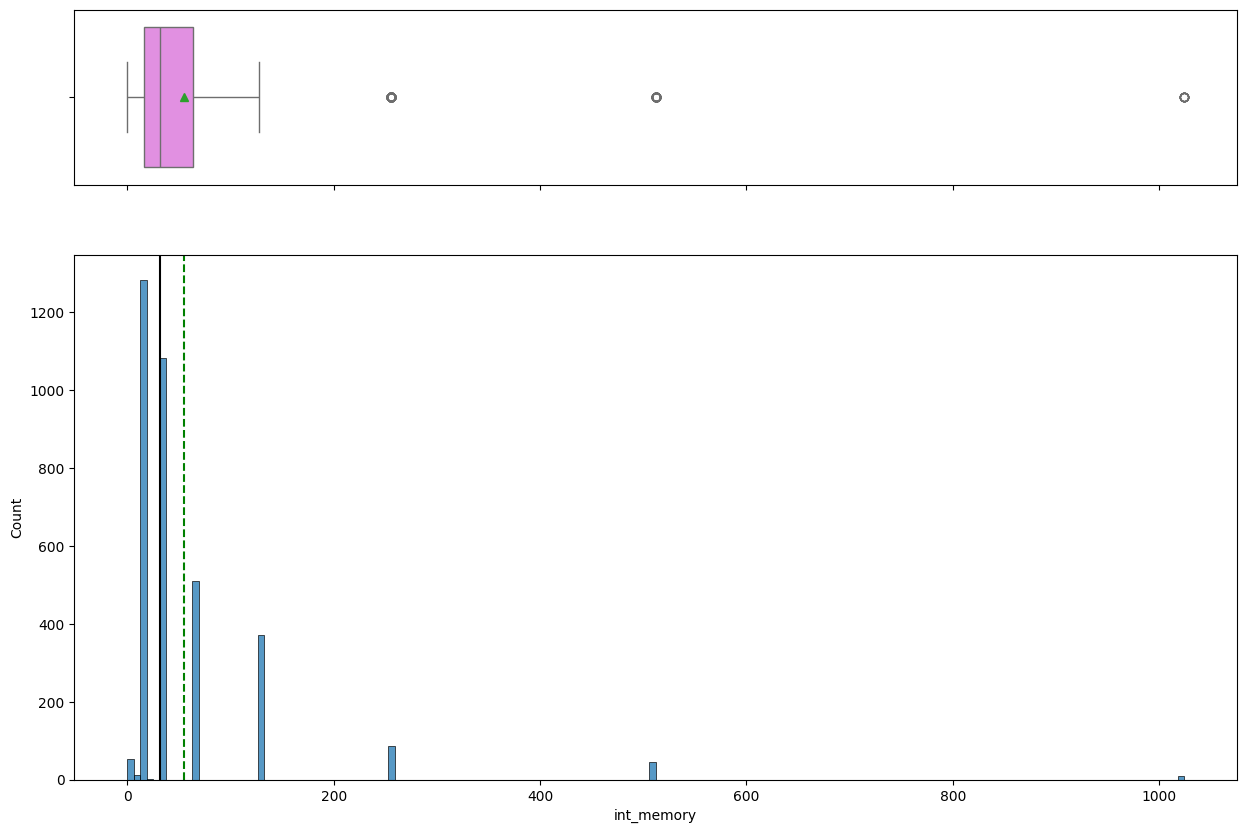

***********************
count    3450.000000
mean       54.573099
std        84.972371
min         0.010000
25%        16.000000
50%        32.000000
75%        64.000000
max      1024.000000
Name: int_memory, dtype: float64
There are 3450 total values in  int_memory


In [350]:
#c31
#simple analysis of numeric ( int64 / float 64 ) values
col ="int_memory"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

#### **ram**  Amount of RAM in GB
Observations
* There are four missing values all from the others category... all branded Nokia
* The distribution is normal with a pronounced center at 4MB
* There are outliers all the way to 12 MB... expect positive orellation with price


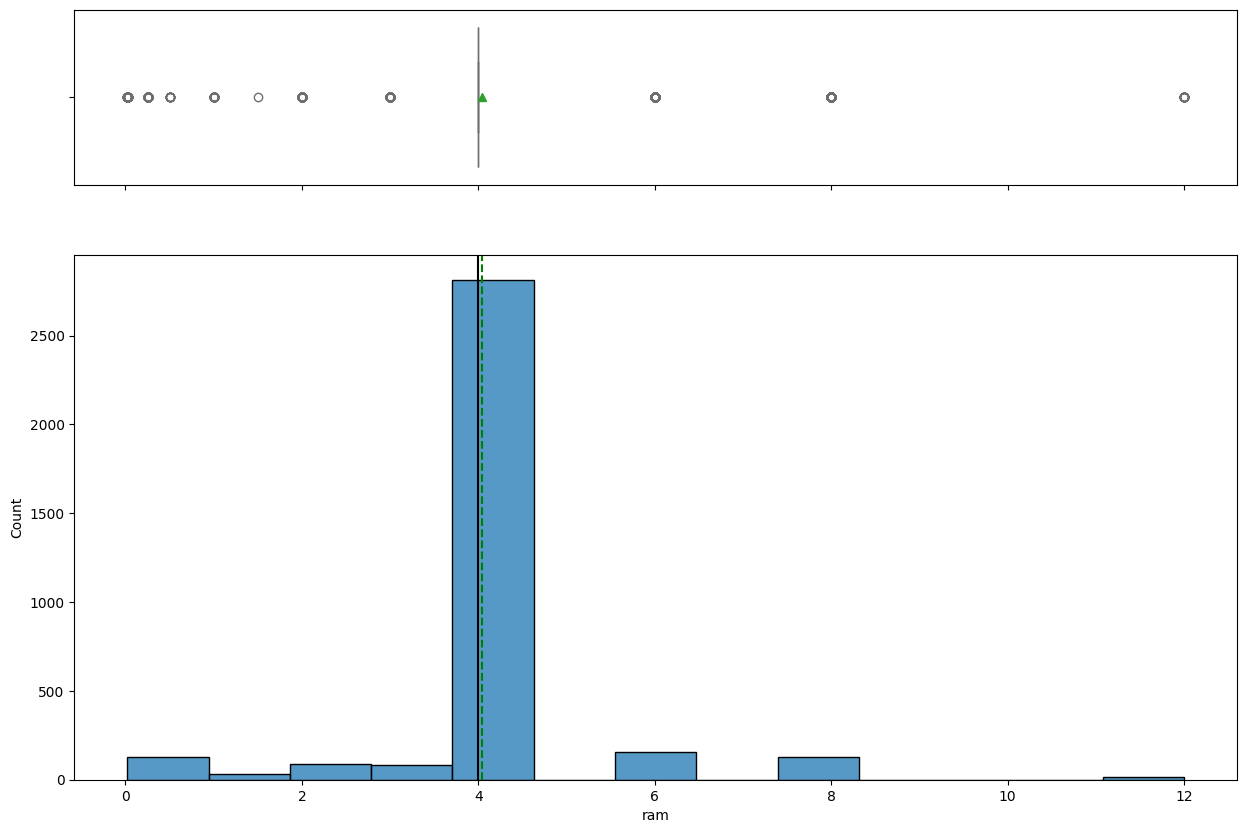

***********************
count    3450.000000
mean        4.036122
std         1.365105
min         0.020000
25%         4.000000
50%         4.000000
75%         4.000000
max        12.000000
Name: ram, dtype: float64
There are 3450 total values in  ram


In [351]:
#c32
#simple analysis of numeric ( int64 / float 64 ) values
col ="ram"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

In [352]:
#C33
#look at missing ram accross os
cat="os"
num="ram"
missing_values(df, cat,num)

*** categorical is: os 
*** numerical is:  ram


,os,ram,min_ram,max_ram,mean_ram,median_ram,std_ram,missing_ram,missing_percent
0,Others,137,0.02,6.0,1.861805,0.25,1.955112,4,2.92%


In [353]:
#C34
#look at missing ram accross os
cat="brand_name"
num="ram"
missing_values(df, cat,num)

*** categorical is: brand_name 
*** numerical is:  ram


,brand_name,ram,min_ram,max_ram,mean_ram,median_ram,std_ram,missing_ram,missing_percent
0,Nokia,106,0.02,6.0,2.420294,4.0,1.889325,4,3.77%


#### **battery** Energy capacity of the device battery in mAh
Observations
* there are 6 missing values all 2016 or older accross android, microsoft and other os
* the distribution is normal skewed right with many outliers above the max whisker

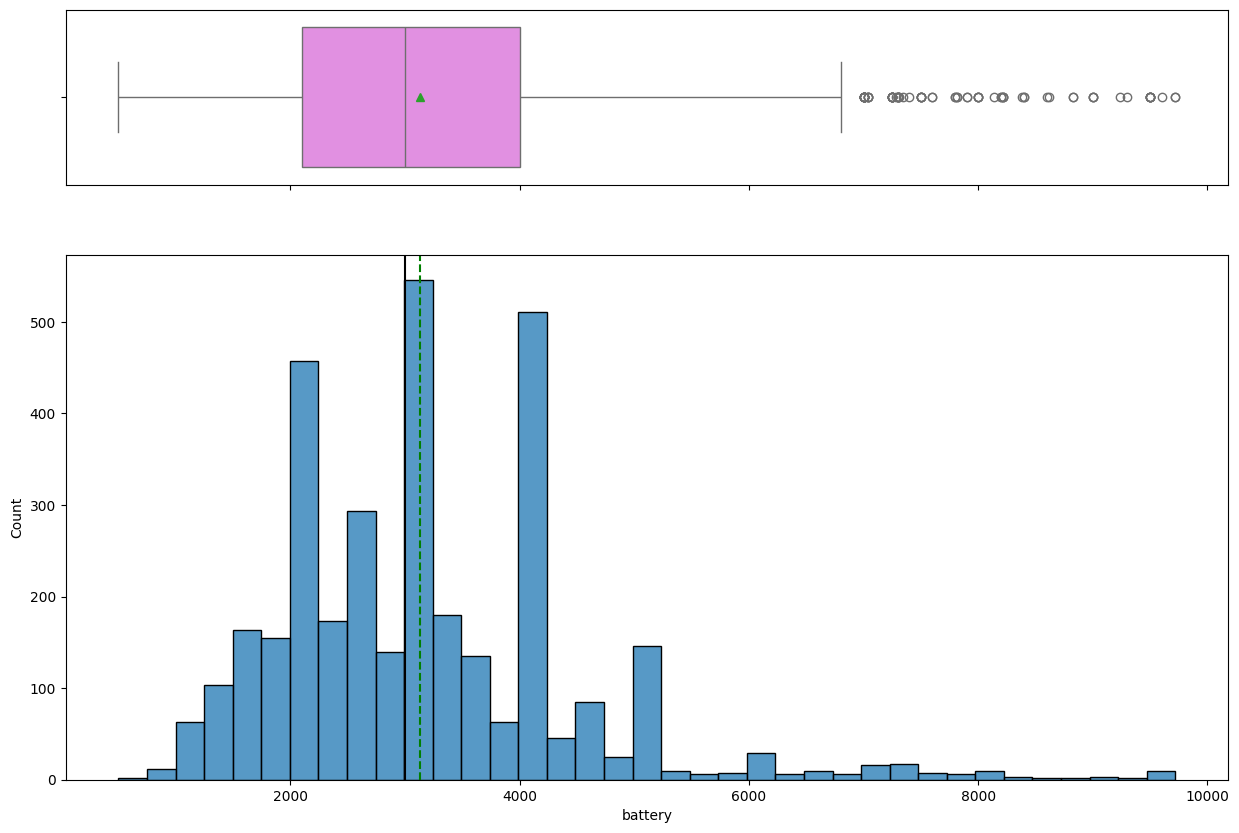

***********************
count    3448.000000
mean     3133.402697
std      1299.682844
min       500.000000
25%      2100.000000
50%      3000.000000
75%      4000.000000
max      9720.000000
Name: battery, dtype: float64
There are 3448 total values in  battery


In [354]:
#C35
#simple analysis of numeric ( int64 / float 64 ) values
col ="battery"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

In [355]:
#C36
#look at missing
cat="os"
num="battery"
missing_values(df, cat,num)

*** categorical is: os 
*** numerical is:  battery


,os,battery,min_battery,max_battery,mean_battery,median_battery,std_battery,missing_battery,missing_percent
2,Windows,67,1200.0,4150.0,2169.696970,2000.0,609.972811,1,1.49%
1,Others,137,620.0,9720.0,1738.981481,1400.0,1224.986397,2,1.46%
0,Android,3214,500.0,9600.0,3198.318281,3000.0,1246.931207,3,0.09%


In [356]:
#c37
#look at missing
cat="brand_name"
num="battery"
missing_values(df, cat,num)

*** categorical is: brand_name 
*** numerical is:  battery


,brand_name,battery,min_battery,max_battery,mean_battery,median_battery,std_battery,missing_battery,missing_percent
1,Meizu,62,2400.0,4500.0,3368.220339,3150.0,523.260470,3,4.84%
2,Microsoft,22,1500.0,3340.0,2382.380952,2500.0,646.650251,1,4.55%
0,Nokia,106,1000.0,5300.0,2259.615385,2000.0,1079.475712,2,1.89%


In [357]:
#C38
#look at missing
cat="release_year"
num="battery"
missing_values(df, cat,num)

*** categorical is: release_year 
*** numerical is:  battery


,release_year,battery,min_battery,max_battery,mean_battery,median_battery,std_battery,missing_battery,missing_percent
2,2016,383,1400.0,9300.0,3169.422572,3000.0,1082.883377,2,0.52%
0,2014,642,750.0,9600.0,2643.458529,2200.0,1382.988227,3,0.47%
1,2013,570,620.0,9000.0,2305.588752,2000.0,1225.211018,1,0.18%


#### **weight**  Weight of the device in grams
* Normal right skew distro
* many outliers above the max whisker
* 7 missing values all from release year 2015 accross windos and android os

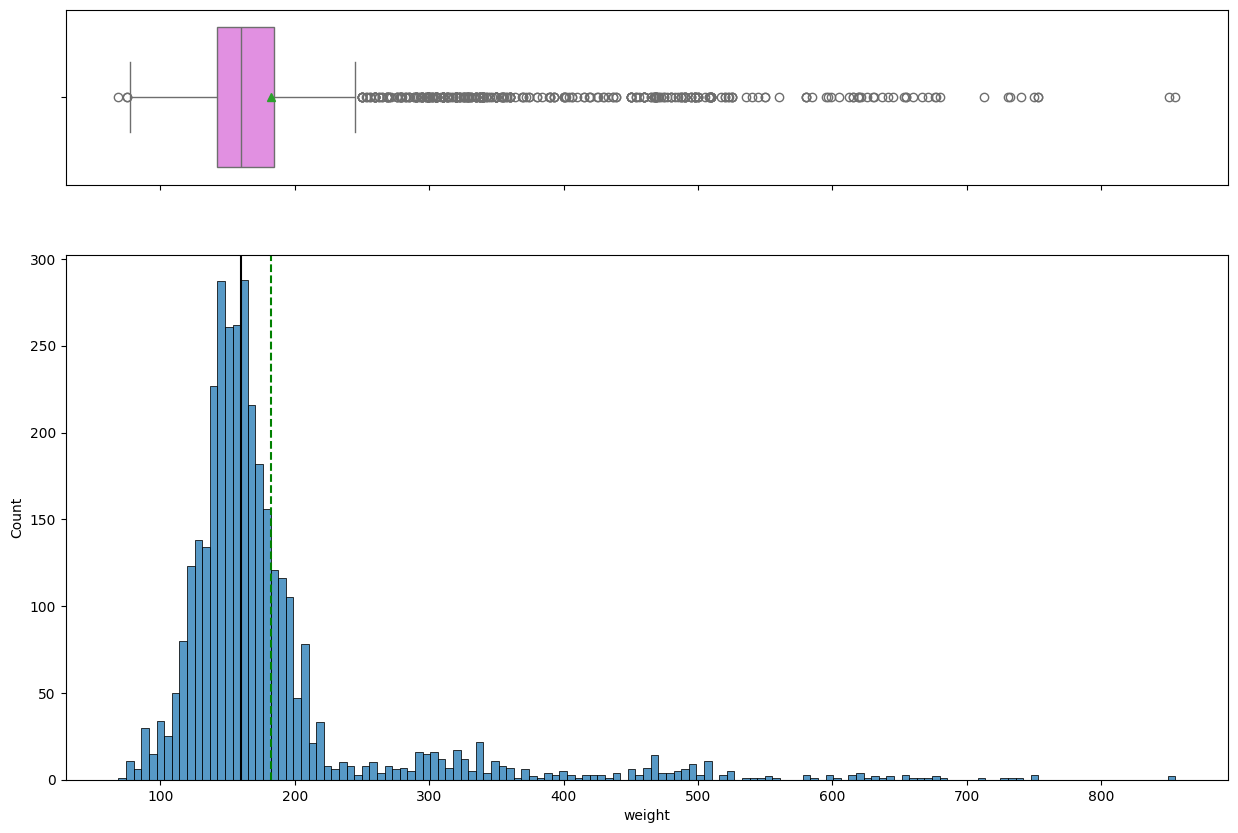

***********************
count    3447.000000
mean      182.751871
std        88.413228
min        69.000000
25%       142.000000
50%       160.000000
75%       185.000000
max       855.000000
Name: weight, dtype: float64
There are 3447 total values in  weight


In [358]:
#c39
#simple analysis
col ="weight"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

In [359]:
#C40
#look at missing
cat="os"
num="weight"
missing_values(df, cat,num)

*** categorical is: os 
*** numerical is:  weight


,os,weight,min_weight,max_weight,mean_weight,median_weight,std_weight,missing_weight,missing_percent
1,Windows,67,98.9,675.9,160.900000,145.5,89.077422,1,1.49%
0,Android,3214,75.0,855.0,184.040056,161.0,85.768241,6,0.19%


In [360]:
#C41
#look at missing
cat="release_year"
num="weight"
missing_values(df, cat,num)

*** categorical is: release_year 
*** numerical is:  weight


,release_year,weight,min_weight,max_weight,mean_weight,median_weight,std_weight,missing_weight,missing_percent
0,2015,515,78.4,855.0,175.025787,153.0,89.318817,7,1.36%


#### **release_year**  Year when the device model was released
Observations
* no blank values
* 50% of th 3,454 devise are from 2013,4 and 5

/tmp/ipykernel_1420/372482018.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


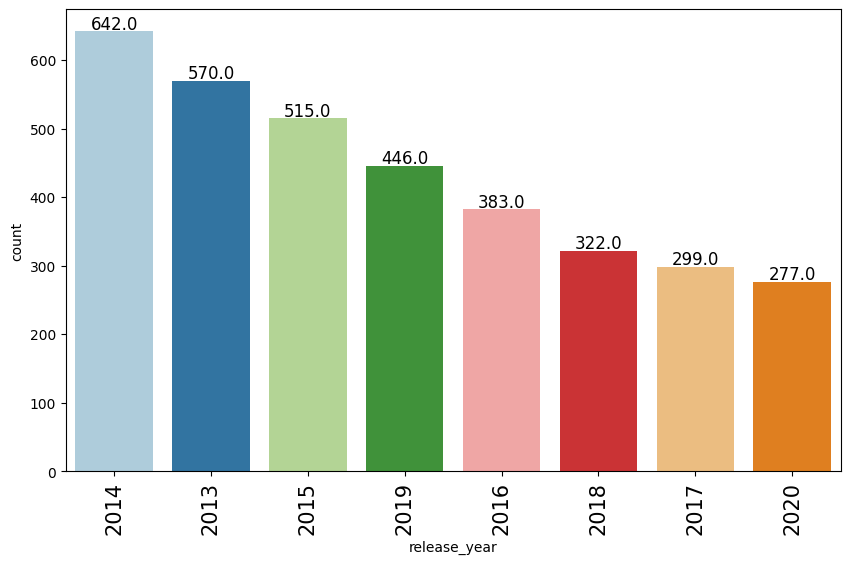

              count percentage
release_year                  
2014            642      18.6%
2013            570      16.5%
2015            515      14.9%
2019            446      12.9%
2016            383      11.1%
2018            322       9.3%
2017            299       8.7%
2020            277       8.0%
There are 3454 total values in  release_year


In [361]:
#C42
#simple analysis of object ( categorical ) values
col ="release_year"
labeled_barplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

#### **days_used**  Number of days the used/refurbished device has been used
Observations
* no missing values
* normal left skewed distribution
*

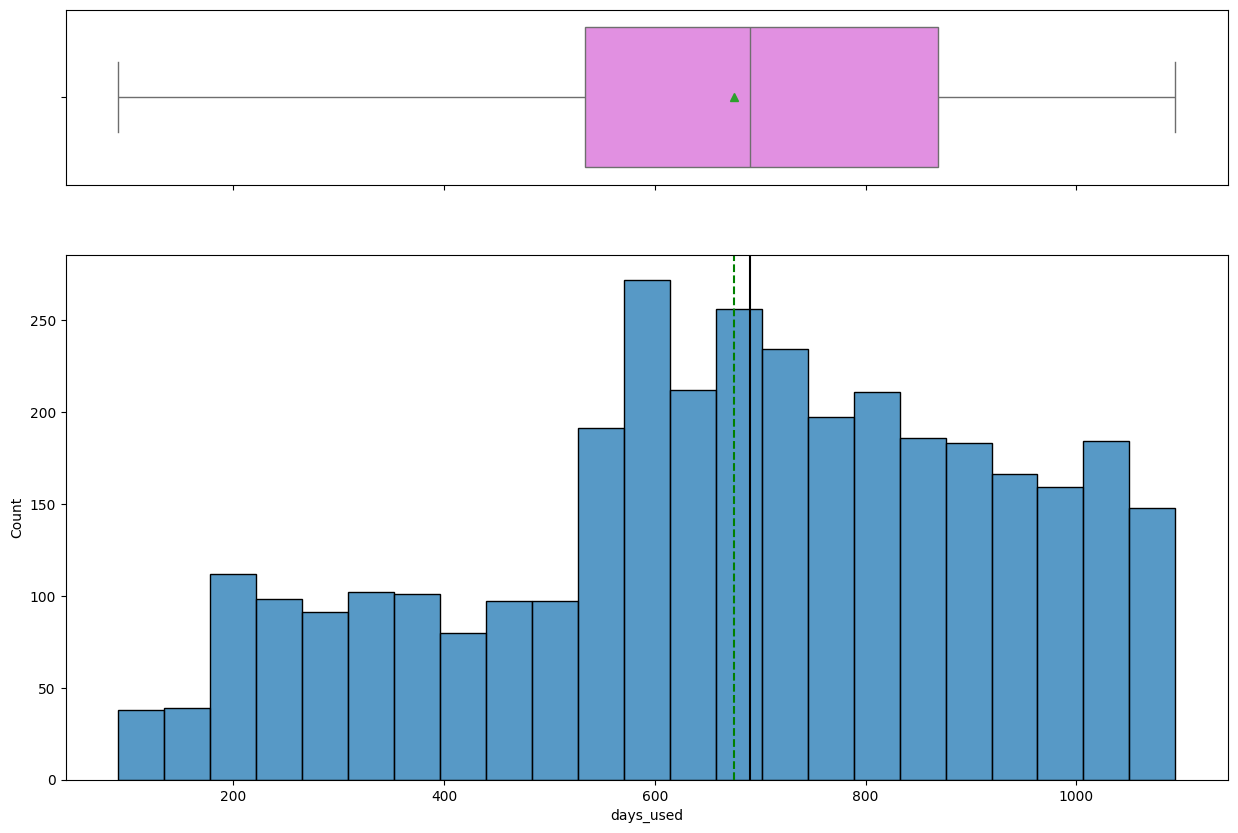

***********************
count    3454.000000
mean      674.869716
std       248.580166
min        91.000000
25%       533.500000
50%       690.500000
75%       868.750000
max      1094.000000
Name: days_used, dtype: float64
There are 3454 total values in  days_used


In [362]:
#C43
#simple analysis of numeric ( int64 / float 64 ) values
col ="days_used"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

#### **normalized_used_price**  Normalized price of the used/refurbished device in euros
Observations
* No missing values
* normal distribution with slight left skew.
* There are outliers .... more on the left indicatinting skew

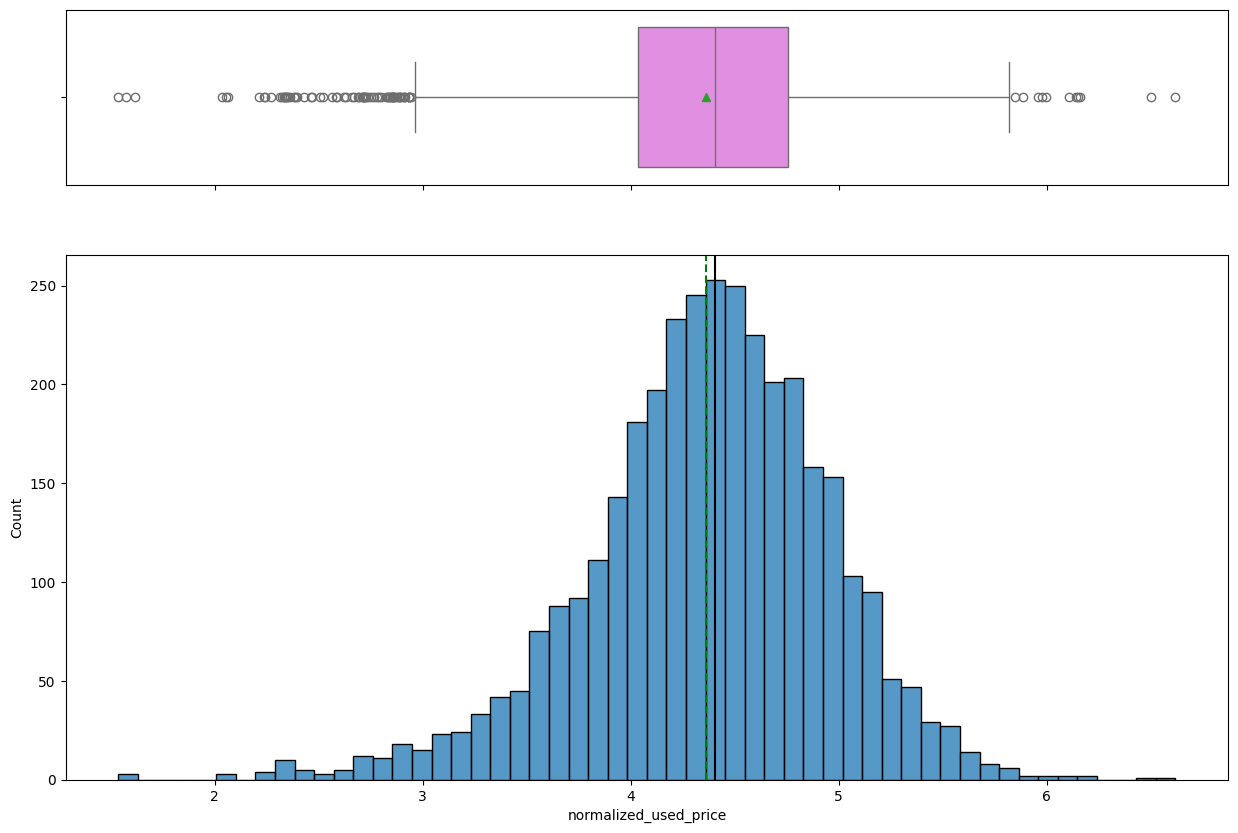

***********************
count    3454.000000
mean        4.364712
std         0.588914
min         1.536867
25%         4.033931
50%         4.405133
75%         4.755700
max         6.619433
Name: normalized_used_price, dtype: float64
There are 3454 total values in  normalized_used_price


In [363]:
#C44
#simple analysis of numeric ( int64 / float 64 ) values
col ="normalized_used_price"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

#### **normalized_new_price** Normalized price of the used/refurbished device in euros
Observations
* No missing values
* Normal distribution
* an approximately equal number of outliers below and above the whiskers
* no skew

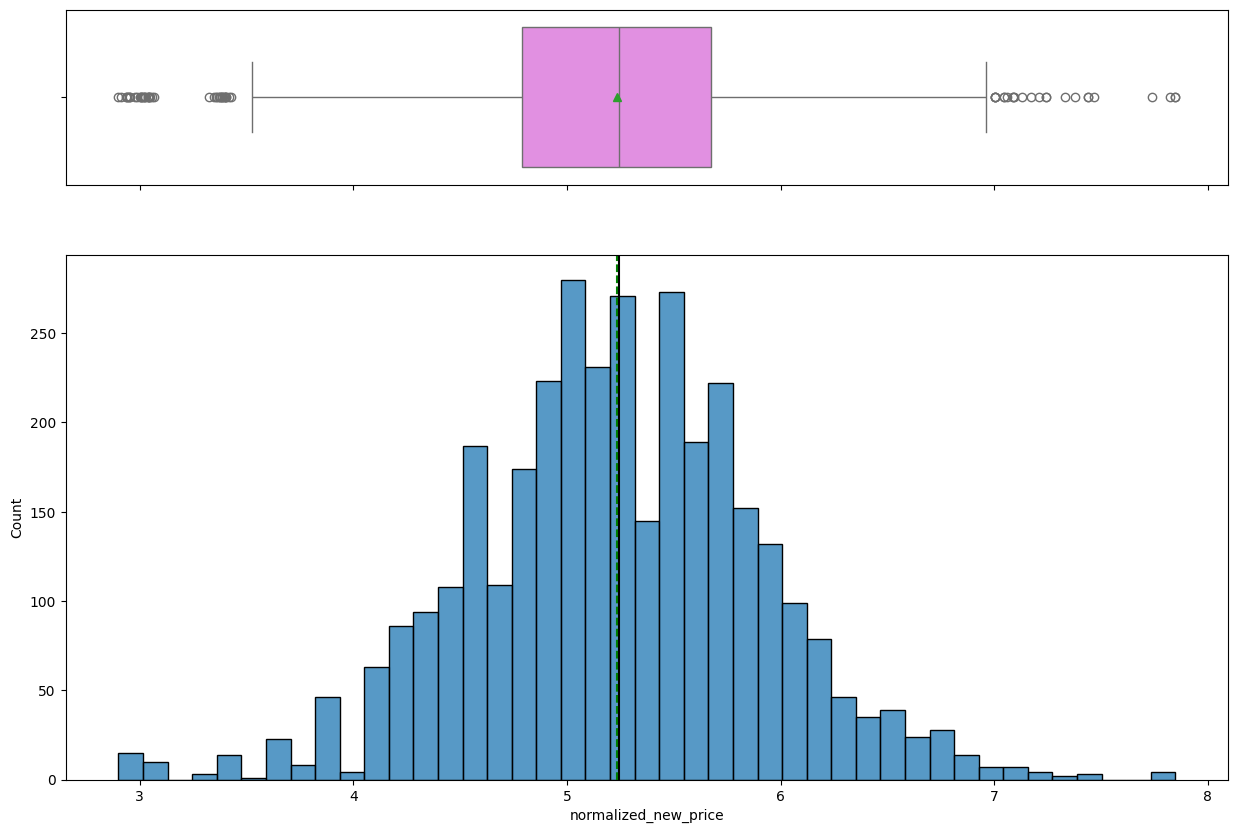

***********************
count    3454.000000
mean        5.233107
std         0.683637
min         2.901422
25%         4.790342
50%         5.245892
75%         5.673718
max         7.847841
Name: normalized_new_price, dtype: float64
There are 3454 total values in  normalized_new_price


In [364]:
#c45
#simple analysis of numeric ( int64 / float 64 ) values
col ="normalized_new_price"
histogram_boxplot(df,col)
print('There are', df[col]. count(), 'total values in ' , col)

### BIVARIATE ANALYSIS:

#### Correlation matrix

- Strongest with the target: **new price (0.83)**. Then screen, selfie camera, battery (~0.61), main camera (0.59).
- **int_memory** is weak with used price (0.19).
- **days_used** vs used price is negative (−0.36). Newer phones also have fewer days used (year vs days_used **−0.75**).
- Three pairs above 0.8: used–new **0.83**, screen–weight **0.83**, screen–battery **0.81** (size cluster).

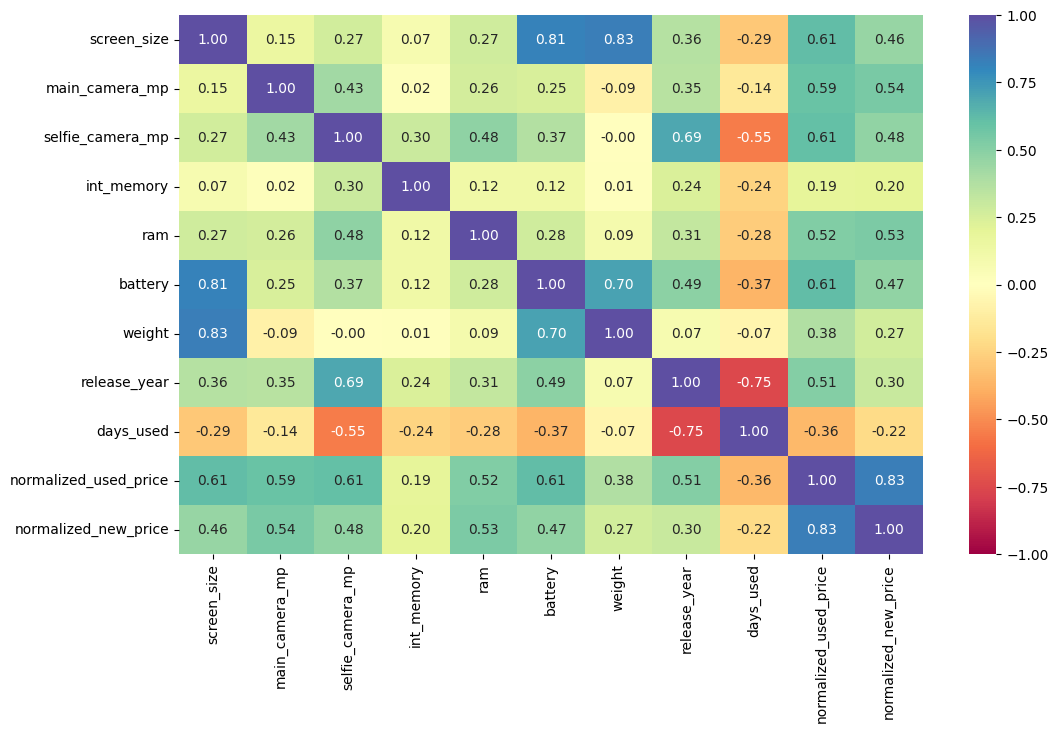

In [365]:
#C45
#creating a list of numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

#plot a heat map for the 10 numerics ['screen_size','main_camera_mp','selfie_camera_mp','int_memory','ram','battery','weight','days_used','normalized_used_price','normalized_new_price']
plt.figure(figsize=(12, 7))
sns.heatmap(df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()


#### Focused Pairs

Picking pairs that univariate and the correlation matrix already flagged.

 **target** (`normalized_used_price`) v **Numeric**

- normalized_used_price v normalized_new_price , scatter (r ≈ 0.83).
- normalized_used_price v screen_size.
- normalized_used_price v release_year.

**target** (`normalized_used_price`) v **Category**

- normalized_used_price  v 4g
- normalized_used_price v os
- normalized_used_price v brand_name
- normalized_used_price v 5g
- normalized_used_price vs days_used



###### normalized_new_price v normalized_used_price

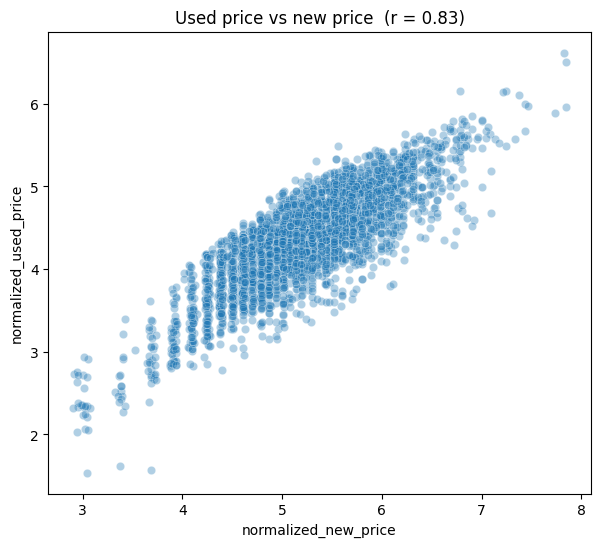

In [366]:
#C46
#normalized_new_price versus normalized used price, Scatter visualizing r = 0.83
x = "normalized_new_price"
y = "normalized_used_price"
r = df[x].corr(df[y])

plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x=x, y=y, alpha=0.35)
plt.title(f"Used price vs new price  (r = {r:.2f})")
plt.show()


###### screen_size normalized_used_orice





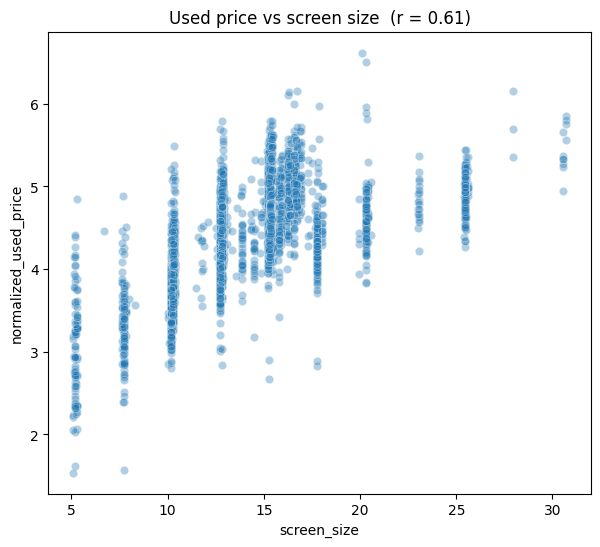

In [367]:
#C47
#screen_size versus normalized used price, Scatter visualizing r = 0.61
x = "screen_size"
y = "normalized_used_price"
r = df[x].corr(df[y])

plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x=x, y=y, alpha=0.35)
plt.title(f"Used price vs screen size  (r = {r:.2f})")
plt.show()


##### release_year versus normalized used price
- newer releases correlate to  higher prices

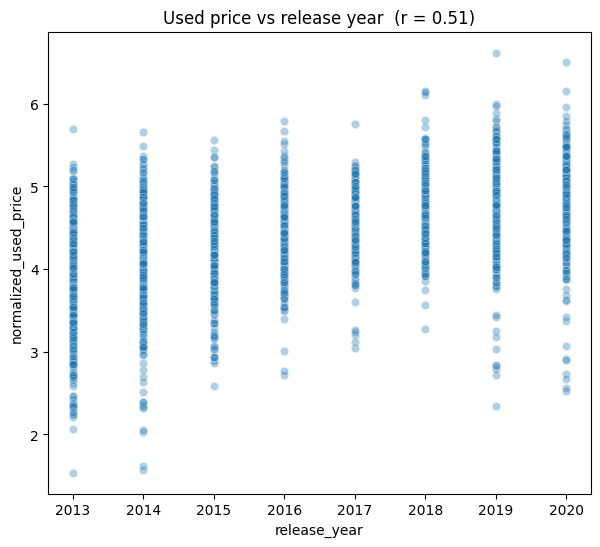

In [368]:
#C48
#release_year versus normalized used price, Scatter visualizing r = 0.51
x = "release_year"
y = "normalized_used_price"
r = df[x].corr(df[y])

plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x=x, y=y, alpha=0.35)
plt.title(f"Used price vs release year  (r = {r:.2f})")
plt.show()


##### days_used v normalized_used_price
- newer units are less worn and lift price

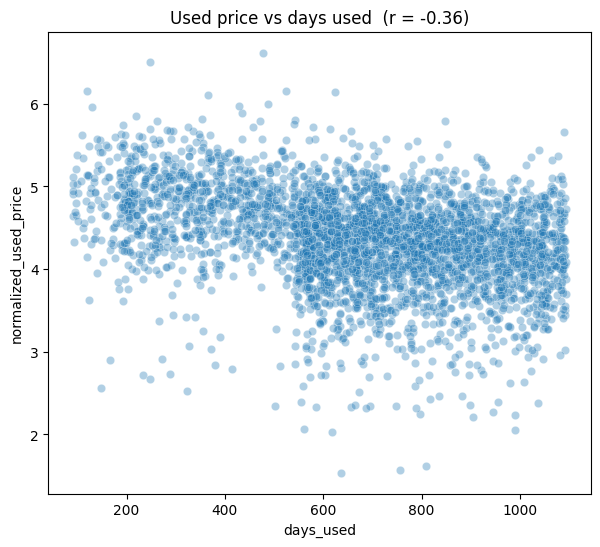

In [369]:
#C49 -  days_used v normalized_used_price

x = "days_used"
y = "normalized_used_price"
r = df[x].corr(df[y])

plt.figure(figsize=(7, 6))
sns.scatterplot(data=df, x=x, y=y, alpha=0.35)
plt.title(f"Used price vs days used  (r = {r:.2f})")
plt.show()

##### 4g v normalized_used_price
4G units have a higher used price (median 4.57 vs 3.95). Some of that is “4G comes with newer / better phones,” so the first ordinary least squares (OLS) should include year or new price before you treat 4G as a pure premium.


In [370]:
#C50

print(
    df.groupby("4g")["normalized_used_price"]
    .describe()
    .round(2)
    .sort_values(by='50%', ascending=False)
    .to_string()
)

      count  mean   std   min   25%   50%   75%   max
4g                                                   
yes  2335.0  4.59  0.45  2.67  4.30  4.57  4.88  6.62
no   1119.0  3.90  0.57  1.54  3.58  3.95  4.26  5.49


#####5g v normalized_used_price
5G listings have a higher used price (median 5.18 vs 4.37), but there are only 152 of them. Treat 5G as a flag for “newer flagship,” not as a 0.8-point premium by itself, until Ordinary Least Squares (OLS) includes new price and year.


In [371]:
#C51
# 5g v normalized_used_price
print(
    df.groupby("5g")["normalized_used_price"]
    .describe()
    .round(2)
    .sort_values(by='50%', ascending=False)
    .to_string()
)

      count  mean   std   min   25%   50%   75%   max
5g                                                   
yes   152.0  5.23  0.34  4.60  4.99  5.18  5.45  6.62
no   3302.0  4.33  0.57  1.54  4.01  4.37  4.71  6.16


In [372]:
cat="release_year"
num ="main_camera_mp"
missing_values(df,cat,num)

*** categorical is: release_year 
*** numerical is:  main_camera_mp


,release_year,main_camera_mp,min_main_camera_mp,max_main_camera_mp,mean_main_camera_mp,median_main_camera_mp,std_main_camera_mp,missing_main_camera_mp,missing_percent
3,2020,277,0.3,13.0,8.274194,8.0,4.359046,122,44.04%
0,2019,446,0.3,48.0,11.290773,12.2,4.727816,45,10.09%
1,2018,322,0.3,24.0,12.385256,13.0,2.900500,10,3.11%
2,2017,299,0.3,23.0,11.754209,13.0,3.656223,2,0.67%


### **Questions**:

####Q1. What does the distribution of normalized used device prices look like?

Used price is mound-shaped and fairly tight (mean ≈ median ≈ 4.4, std 0.59).
A short left tail and a short right tail sit outside the boxplot fences; treat them as cheap vs flagship units, not as a reason to clip before Ordinary Least Squares (OLS).

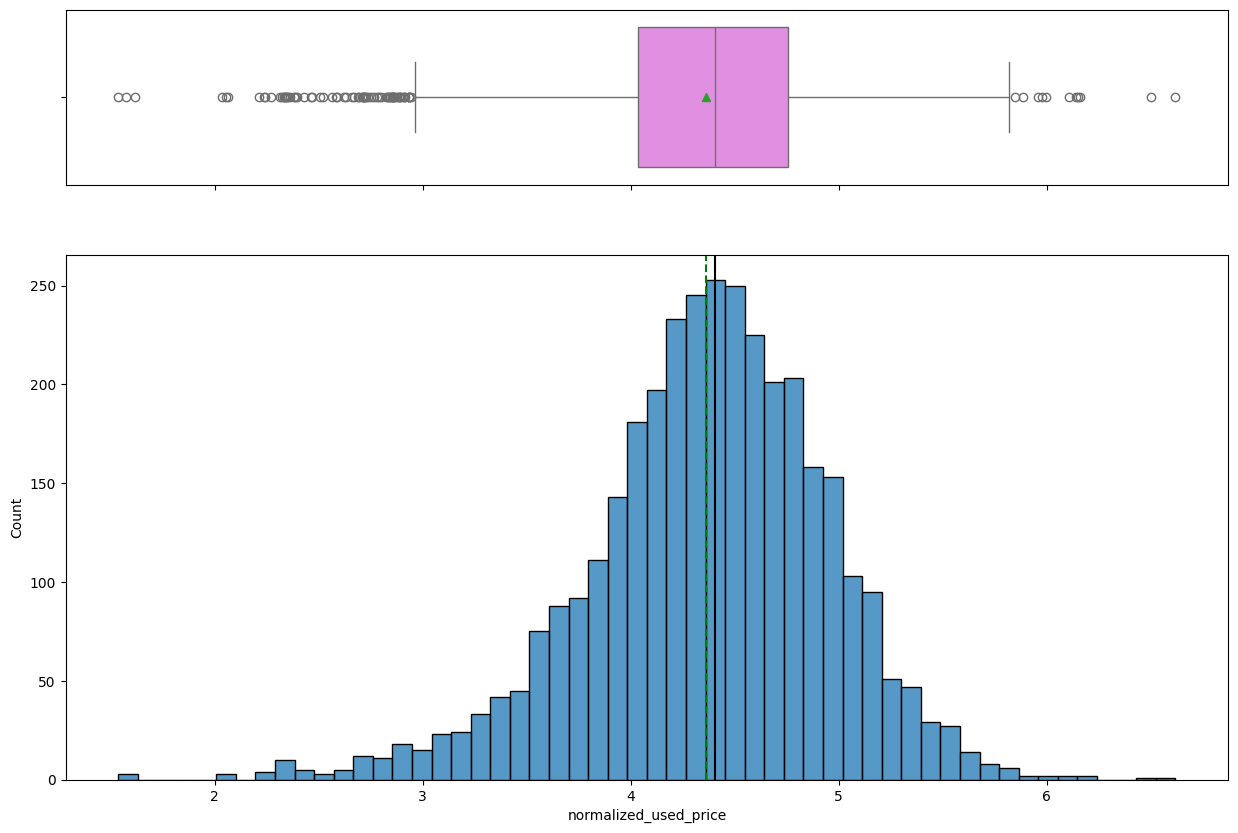

***********************
count    3454.000000
mean        4.364712
std         0.588914
min         1.536867
25%         4.033931
50%         4.405133
75%         4.755700
max         6.619433
Name: normalized_used_price, dtype: float64


In [373]:
#C52
histogram_boxplot(df,"normalized_used_price")


####Q2. What percentage of the used device market is dominated by Android devices?

* 93.1 % of the market (India) is made up of android devices.
Android is 93.1% (3,214 of 3,454). Others 4.0%, Windows 1.9%, iOS 1.0%.



/tmp/ipykernel_1420/372482018.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


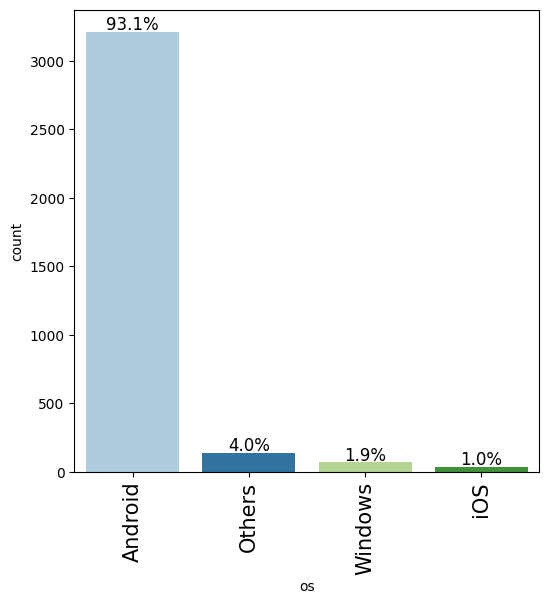

         count percentage
os                       
Android   3214      93.1%
Others     137       4.0%
Windows     67       1.9%
iOS         36       1.0%


In [374]:
#C53
labeled_barplot(df,"os" , perc=True, n=None)

####Q3. How does RAM vary by brand?

Most brands sit on 4 GB (the 25th, 50th, and 75th percentiles of the whole file are all 4).
A few brands extend lower or up to 12 GB (e.g. OnePlus). Min-to-max looks wide; the typical phone does not.
RAM is a weak candidate for Ordinary Least Squares (OLS) because it barely varies.

In [375]:
#C55

print(
    df.groupby("brand_name")["ram"]
    .agg(["count", "median", "min", "max"])
    .sort_values("median")
    .round(2)
    .to_string()
)

            count  median   min   max
brand_name                           
Celkon         33    0.25  0.25   4.0
Infinix        10    2.00  2.00   4.0
Apple          39    4.00  2.00   6.0
Acer           51    4.00  1.00   4.0
Asus          122    4.00  2.00   8.0
BlackBerry     22    4.00  0.25   4.0
Coolpad        22    4.00  3.00   4.0
Alcatel       121    4.00  0.25   4.0
Gionee         56    4.00  0.25   4.0
Google         15    4.00  4.00   6.0
Honor         116    4.00  2.00   8.0
HTC           110    4.00  3.00   6.0
Huawei        251    4.00  0.25  12.0
Karbonn        29    4.00  0.25   4.0
LG            201    4.00  0.25   8.0
Lava           36    4.00  0.25   4.0
Lenovo        171    4.00  0.25   6.0
Meizu          62    4.00  2.00   8.0
Micromax      117    4.00  0.25   4.0
Microsoft      22    4.00  4.00   4.0
Motorola      106    4.00  2.00  12.0
Nokia         102    4.00  0.02   6.0
Oppo          129    4.00  1.00  12.0
Others        502    4.00  0.25   8.0
Sony        

####Q4. How does weight vary for devices with large batteries (more than 4500 mAh)?

406 devices have batteries ≥ 4500 mAh.
Half still weigh 220 g or less (phones with big batteries). The upper quarter is much heavier (75th percentile 450 g, max 855 g) — tablets.
A large battery often comes with a large body; it is not a separate “heavy battery” column.


In [376]:
#C56
#create a tmp dataset with battery value >= 4500 mah
col ="battery"
row= "weight"
# create new filtered df
df_tmp = df.query("battery >= 4500")
# describer the weight
df_tmp[row].describe()

,weight
count,406.000000
mean,313.110345
std,150.771672
min,118.000000
25%,196.700000
50%,220.000000
75%,450.000000
max,855.000000


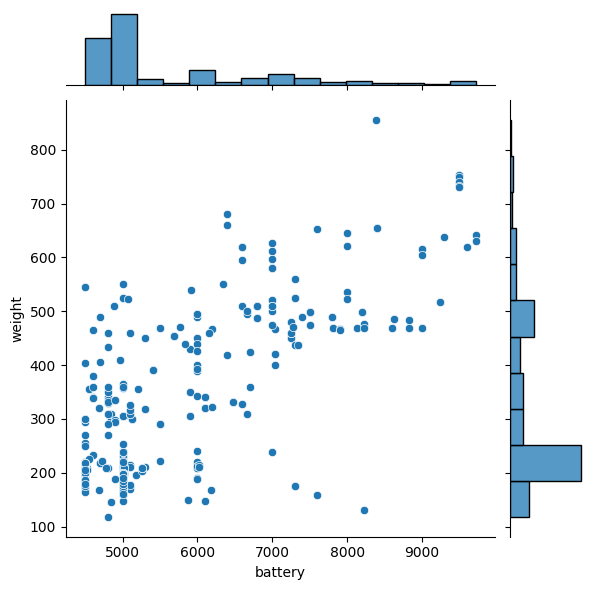

In [377]:
#C56.1
#A jointplot helps to quickly visualize the bivariate and univariate profiles on the same plot.
# It comprises three plots - one displays the relationship between two variables while the other two show the individual distribution of each variable in the margins.
col ="battery"
row= "weight"
sns.jointplot(data=df_tmp, x=col, y=row);

####Q5. How many devices have screens larger than 6 inches, by brand?

1,099 devices (about 32% of 3,454) have screens > 6 inches.
Huawei (149) and Samsung (119) have the most such listings; Others adds 99.
This is a count of rows, not a quality ranking. Small brands can still be *all* large-screen (Infinix: 10 of 10).


/tmp/ipykernel_1420/372482018.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


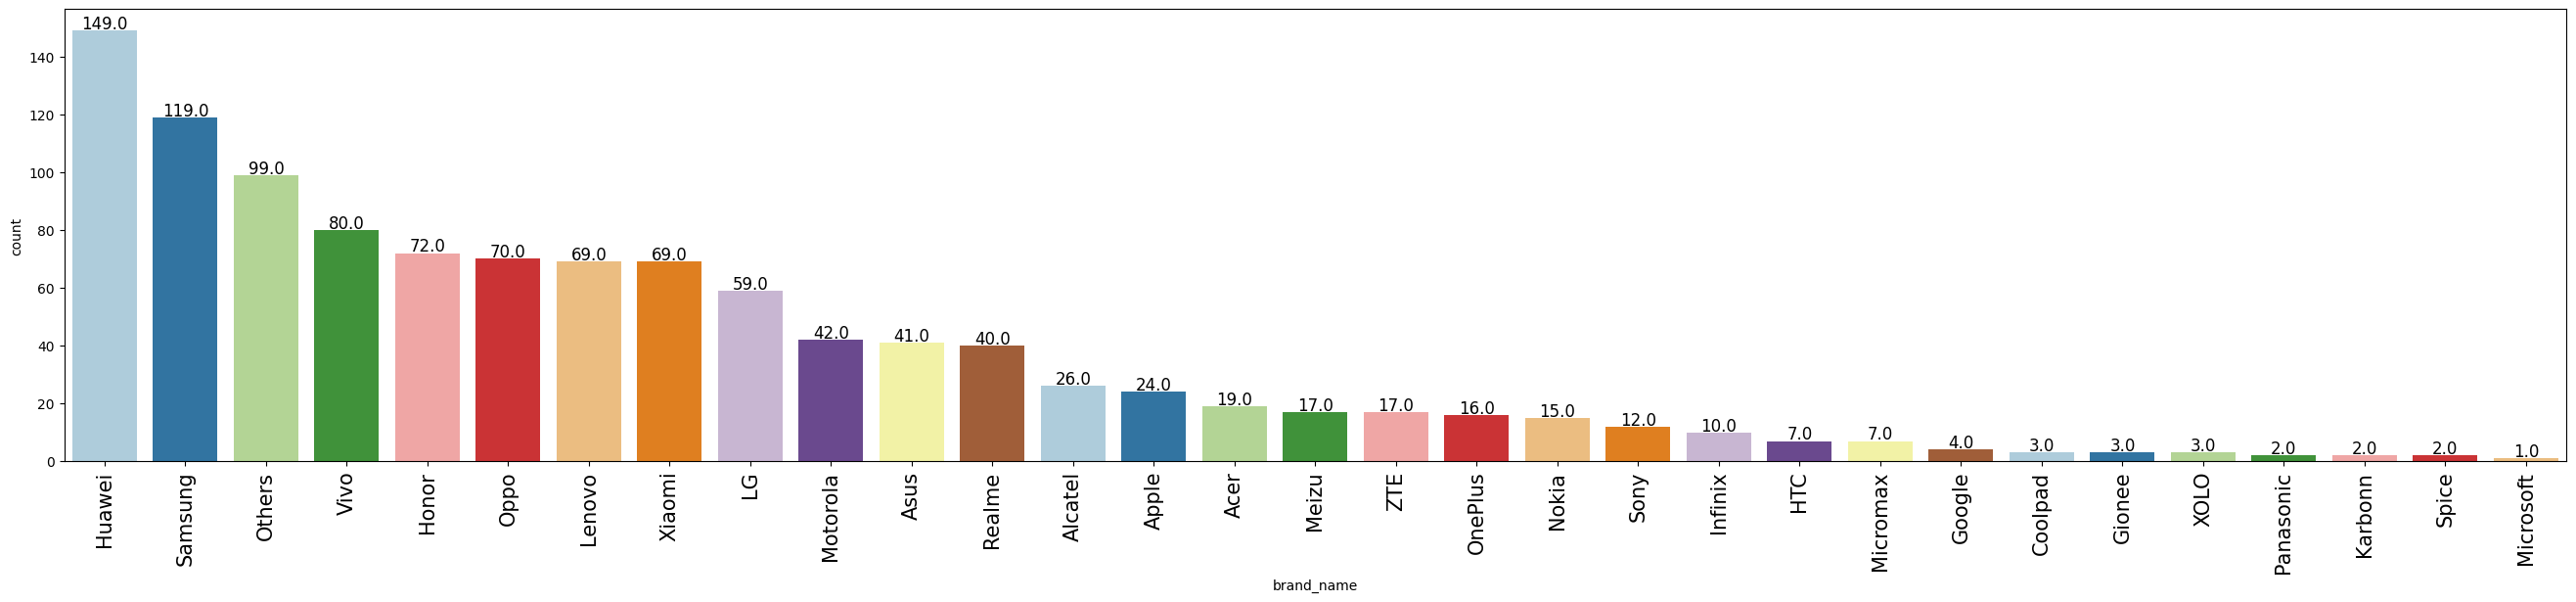

            count percentage
brand_name                  
Huawei        149      13.6%
Samsung       119      10.8%
Others         99       9.0%
Vivo           80       7.3%
Honor          72       6.6%
Oppo           70       6.4%
Lenovo         69       6.3%
Xiaomi         69       6.3%
LG             59       5.4%
Motorola       42       3.8%
Asus           41       3.7%
Realme         40       3.6%
Alcatel        26       2.4%
Apple          24       2.2%
Acer           19       1.7%
Meizu          17       1.5%
ZTE            17       1.5%
OnePlus        16       1.5%
Nokia          15       1.4%
Sony           12       1.1%
Infinix        10       0.9%
HTC             7       0.6%
Micromax        7       0.6%
Google          4       0.4%
Coolpad         3       0.3%
Gionee          3       0.3%
XOLO            3       0.3%
Panasonic       2       0.2%
Karbonn         2       0.2%
Spice           2       0.2%
Microsoft       1       0.1%
There are 1099 total values in  brand_name


In [378]:
#C57
# add varible to data set for screen size in inches using coversion factor 2.54 cm in an inch
df_big_screen = df.copy()
df_big_screen["screen_size_inches"]= df_big_screen["screen_size"] / 2.54
df_tmp2 = df_big_screen.query("screen_size_inches > 6")
#simple analysis of object ( categorical ) values
col ="brand_name"
labeled_barplot(df_tmp2,col)
print('There are', df_tmp2[col]. count(), 'total values in ' , col)


####Q6. Devices with selfie cameras greater than 8 megapixels(MP), by brand

655 devices (about 19% of the file) have selfie cameras > 8 MP.
Huawei (87), Vivo (78), and Oppo (75) lead the *counts*. That tracks brand size plus a front-camera push, not a ranking of quality.


/tmp/ipykernel_1420/372482018.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


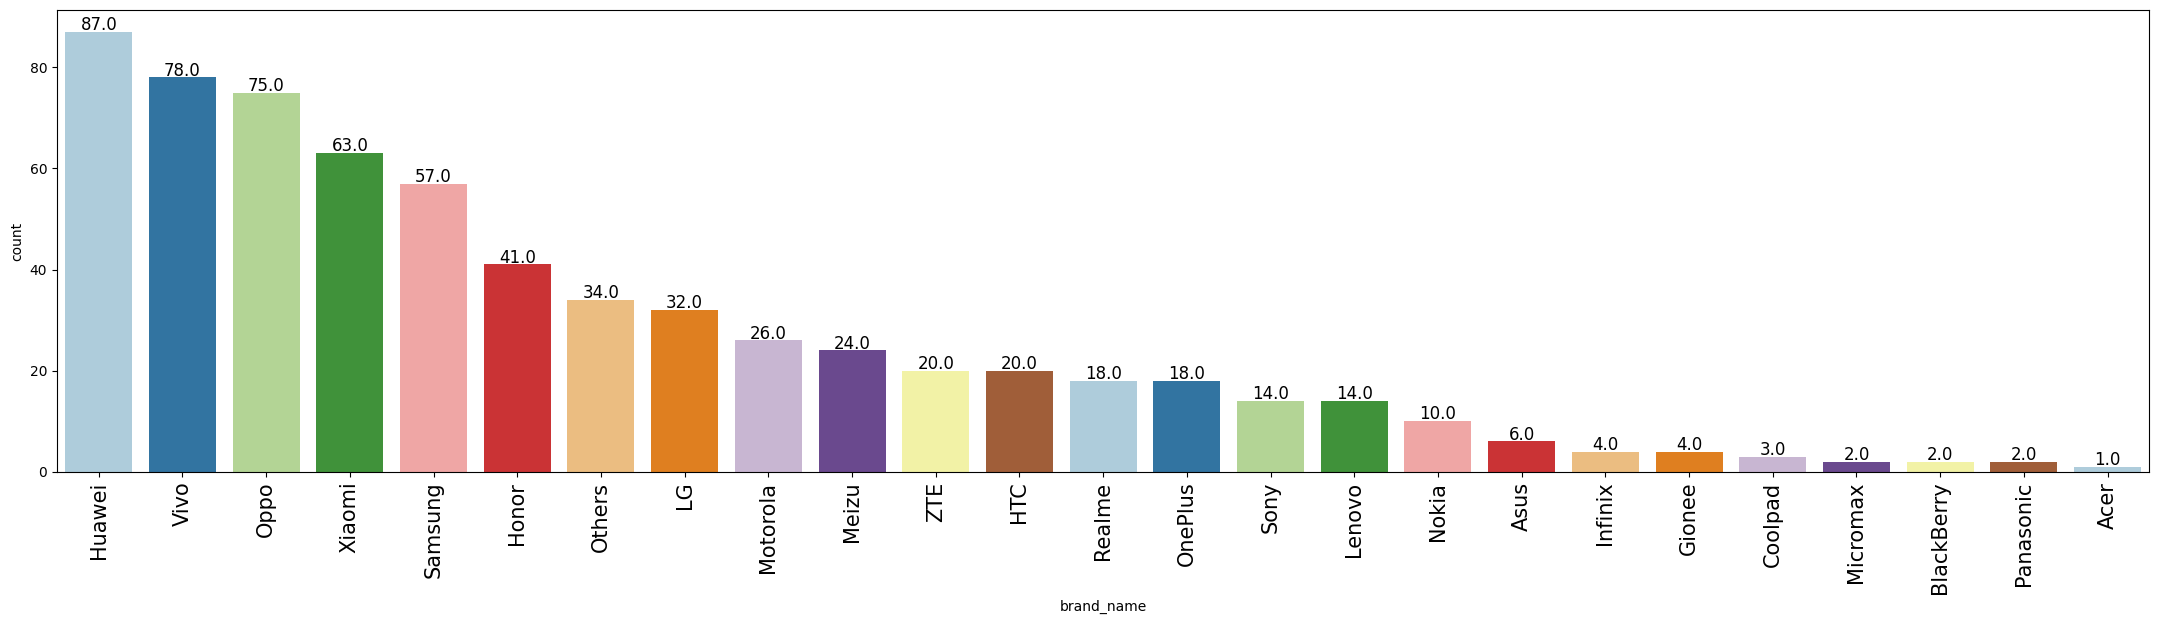

            count percentage
brand_name                  
Huawei         87      13.3%
Vivo           78      11.9%
Oppo           75      11.5%
Xiaomi         63       9.6%
Samsung        57       8.7%
Honor          41       6.3%
Others         34       5.2%
LG             32       4.9%
Motorola       26       4.0%
Meizu          24       3.7%
ZTE            20       3.1%
HTC            20       3.1%
Realme         18       2.7%
OnePlus        18       2.7%
Sony           14       2.1%
Lenovo         14       2.1%
Nokia          10       1.5%
Asus            6       0.9%
Infinix         4       0.6%
Gionee          4       0.6%
Coolpad         3       0.5%
Micromax        2       0.3%
BlackBerry      2       0.3%
Panasonic       2       0.3%
Acer            1       0.2%
There are 655 total values in  brand_name


In [379]:
#C58
# create a filtered data set
df_selfie_cam = df.query("selfie_camera_mp > 8")
#simple analysis of object ( categorical ) values
col ="brand_name"
labeled_barplot(df_selfie_cam,col)
print('There are', df_selfie_cam[col]. count(), 'total values in ' , col)

####Q7. Which attributes are highly correlated with normalized used price?

Strong correlation coefficient(r), |r| ≥ 0.5: new price **0.83**; screen, selfie camera, battery **~0.61**; main camera **0.59**; RAM **0.52**; release year **0.51**.

Moderate: weight **0.38**; days used **−0.36**.

Weak: internal memory **~0.19**.

normalized_new_price is the driver of normalized_used_price (r = 0.83).

Screen / battery / weight are a one size cluster (they also correlate with each other).

Year and days used pull in opposite directions and are in competition with each other.

In [380]:
#C59
# creating a list of numerical columns

num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols

['screen_size',
 'main_camera_mp',
 'selfie_camera_mp',
 'int_memory',
 'ram',
 'battery',
 'weight',
 'release_year',
 'days_used',
 'normalized_used_price',
 'normalized_new_price']

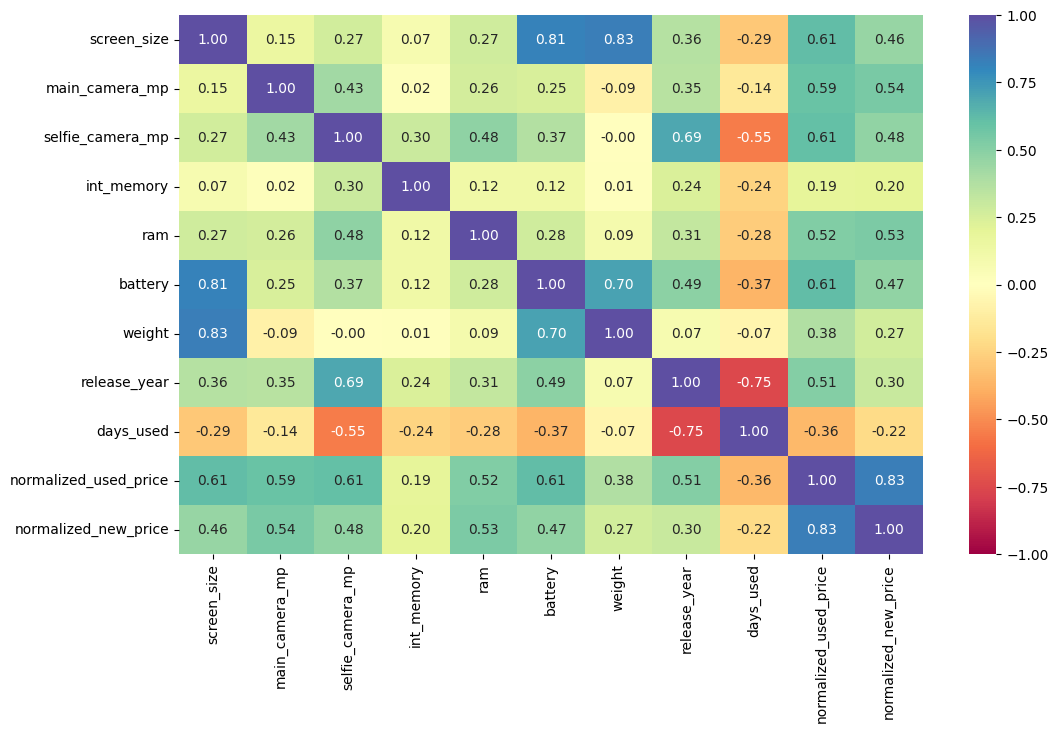

In [381]:
#C60

plt.figure(figsize=(12, 7))
sns.heatmap(
    df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

## Data Preprocessing

### Missing value treatment
*  Mean imputation is often used when the missing values are numerical and the distribution of the variable is approximately normal.
*  Median imputation is preferred when the distribution is skewed, as the median is less sensitive to outliers than the mean.
* Mode imputation is suitable for categorical variables or numerical variables with a small number of unique values.
SIX columns have missing values
1. selfie_camera_mp 2
2. int_memory 4
3. ram 4
4. battery 6
5. weight 7
6. main_camera_mp has 179 missing values... by far the largest use median

**Note :**n = 3,444 after dropping 10 Infinix rows (C62)
Remaining camera holes filled with brand median (C65).

In [382]:
#C61 refresh the df from the backup copy for debugging
# df=df_backup.copy()
# #recast the int64 as an object
# df = df.astype({"release_year": object})

In [383]:
#C62 drop 10 records for Infinix that have no values for main_camera_Mp
#10 Infinix rows dropped; n = 3,444
df=df.loc[df['brand_name'] != 'Infinix'].reset_index(drop = True)

In [384]:
#C63 debugging... print the number of empty values that need treatment
missing_values(df,"brand_name",'main_camera_mp')

*** categorical is: brand_name 
*** numerical is:  main_camera_mp


,brand_name,main_camera_mp,min_main_camera_mp,max_main_camera_mp,mean_main_camera_mp,median_main_camera_mp,std_main_camera_mp,missing_main_camera_mp,missing_percent
9,Realme,41,13.00,13.0,13.000000,13.0,0.000000,36,87.80%
11,OnePlus,22,13.00,16.0,14.200000,13.0,1.643168,17,77.27%
7,Meizu,62,8.00,21.0,13.608511,13.0,2.808050,15,24.19%
12,BlackBerry,22,5.00,21.0,10.333333,8.0,4.405878,4,18.18%
1,Xiaomi,132,8.00,22.5,12.399083,13.0,1.860630,23,17.42%
5,Motorola,106,5.00,48.0,12.920455,13.0,6.789481,18,16.98%
2,Oppo,129,3.15,16.0,10.444495,13.0,3.277634,20,15.50%
13,Coolpad,22,8.00,16.0,11.263158,13.0,2.663375,3,13.64%
4,Vivo,117,5.00,16.0,12.859223,13.0,2.020019,14,11.97%
6,Sony,86,3.15,23.0,14.870886,13.0,6.631837,7,8.14%


In [385]:
#C64 col="main_camera_mp"
df[col].describe()

,brand_name
count,3444
unique,33
top,Others
freq,502


In [386]:
#C65 treat the column with the median value by brand_name and release_year
col="main_camera_mp"
df[col] = df[col].fillna(
    value=df.groupby(["brand_name"
                    #  , "release_year" for some reason this line fails the code... cmeback later
                     ])[col].transform("median")
)


In [387]:
#C66
col="main_camera_mp"
df[col].describe()

,main_camera_mp
count,3444.000000
mean,9.622294
std,4.755529
min,0.080000
25%,5.000000
50%,8.000000
75%,13.000000
max,48.000000


In [388]:
#C67
col="selfie_camera_mp"
df[col].describe()

,selfie_camera_mp
count,3442.000000
mean,6.540732
std,6.972786
min,0.000000
25%,2.000000
50%,5.000000
75%,8.000000
max,32.000000


In [389]:
#C68 treat the column with the median value by brand_name and release_year
col="selfie_camera_mp"
df[col] = df[col].fillna(
    value=df.groupby(["brand_name"
                    #  , "release_year" for some reason this line fails the code... cmeback later
                     ])[col].transform("median")
)

In [390]:
#C69
col="selfie_camera_mp"
df[col].describe()

,selfie_camera_mp
count,3444.000000
mean,6.541580
std,6.970849
min,0.000000
25%,2.000000
50%,5.000000
75%,8.000000
max,32.000000


In [391]:
#C70
col="int_memory"
df[col].describe()

,int_memory
count,3440.000000
mean,54.620113
std,85.088541
min,0.010000
25%,16.000000
50%,32.000000
75%,64.000000
max,1024.000000


In [392]:
#C71 treat the column with the median value by brand_name and release_year
col="int_memory"
df[col] = df[col].fillna(
    value=df.groupby(["brand_name"
                    #  , "release_year" for some reason this line fails the code... cmeback later
                     ])[col].transform("median")
)

In [393]:
#C72
col="int_memory"
df[col].describe()

,int_memory
count,3444.000000
mean,54.575258
std,85.049276
min,0.010000
25%,16.000000
50%,32.000000
75%,64.000000
max,1024.000000


In [394]:
#C73
col="ram"
df[col].describe()

,ram
count,3440.000000
mean,4.040297
std,1.364204
min,0.020000
25%,4.000000
50%,4.000000
75%,4.000000
max,12.000000


In [395]:
#C74 treat the column with the median value by brand_name and release_year
col="ram"
df[col] = df[col].fillna(
    value=df.groupby(["brand_name"
                    #  , "release_year" for some reason this line fails the code... cmeback later
                     ])[col].transform("median")
)

In [396]:
#C75
col="ram"
df[col].describe()

,ram
count,3444.000000
mean,4.040250
std,1.363412
min,0.020000
25%,4.000000
50%,4.000000
75%,4.000000
max,12.000000


In [397]:
#C76
col="battery"
df[col].describe()

,battery
count,3438.000000
mean,3128.555119
std,1297.827427
min,500.000000
25%,2100.000000
50%,3000.000000
75%,4000.000000
max,9720.000000


In [398]:
#C77 treat the column with the median value by brand_name and release_year
col="battery"
df[col] = df[col].fillna(
    value=df.groupby(["brand_name"
                    #  , "release_year" for some reason this line fails the code... cmeback later
                     ])[col].transform("median")
)

In [399]:
#C78
col="battery"
df[col].describe()

,battery
count,3444.000000
mean,3127.735918
std,1297.025474
min,500.000000
25%,2100.000000
50%,3000.000000
75%,4000.000000
max,9720.000000


In [400]:
#C79
col="weight"
df[col].describe()

,weight
count,3437.000000
mean,182.747076
std,88.538383
min,69.000000
25%,142.000000
50%,160.000000
75%,185.000000
max,855.000000


In [401]:
#C80 treat the column with the median value by brand_name and release_year
col="weight"
df[col] = df[col].fillna(
    value=df.groupby(["brand_name"
                    #  , "release_year" for some reason this line fails the code... cmeback later
                     ])[col].transform("median")
)

In [402]:
#C81
col="weight"
df[col].describe()

,weight
count,3444.000000
mean,182.631736
std,88.485261
min,69.000000
25%,142.000000
50%,160.000000
75%,185.000000
max,855.000000


In [403]:
#C82 all varibles treated
df.isnull().sum().sum()

np.int64(0)

### Feature engineering (if needed)
* create a new feature **years_running** by taking the difference between the constant 2021( year data qas currated) and varible release_year.
* Drop the original column(s) once the new feature is created as the year values themselves are not numerical in nature
* Drop release_year because it is a perfect linear pair with years_running.

In [404]:
#C83
#create the column years_running
df["years_running"] = 2021 - df["release_year"].astype(int)
df["years_running"].describe()




,years_running
count,3444.000000
mean,5.045296
std,2.293263
min,1.000000
25%,3.000000
50%,6.000000
75%,7.000000
max,8.000000


In [405]:
#C84
#remove the column create in the previous step
df.drop('release_year', axis=1, inplace=True)

#peak at the df head
df.head()

,brand_name,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_used_price,normalized_new_price,years_running
0,Honor,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.307572,4.715100,1
1,Honor,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.162097,5.519018,1
2,Honor,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.111084,5.884631,1
3,Honor,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.135387,5.630961,1
4,Honor,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.389995,4.947837,1


### Handle Outlier
* There are a outliers in the data in fields
  * weight : right skewed and needs treatment
  * battery: right skewed and needs treatment
* We will drop the column(s)
  * brand_name (too many unique values)


In [406]:
#C85 remove the column
df.drop('brand_name', axis=1, inplace=True)

#peak at the df head
df.head()

,os,screen_size,4g,5g,main_camera_mp,selfie_camera_mp,int_memory,ram,battery,weight,days_used,normalized_used_price,normalized_new_price,years_running
0,Android,14.50,yes,no,13.0,5.0,64.0,3.0,3020.0,146.0,127,4.307572,4.715100,1
1,Android,17.30,yes,yes,13.0,16.0,128.0,8.0,4300.0,213.0,325,5.162097,5.519018,1
2,Android,16.69,yes,yes,13.0,8.0,128.0,8.0,4200.0,213.0,162,5.111084,5.884631,1
3,Android,25.50,yes,yes,13.0,8.0,64.0,6.0,7250.0,480.0,345,5.135387,5.630961,1
4,Android,15.32,yes,no,13.0,8.0,64.0,3.0,5000.0,185.0,293,4.389995,4.947837,1


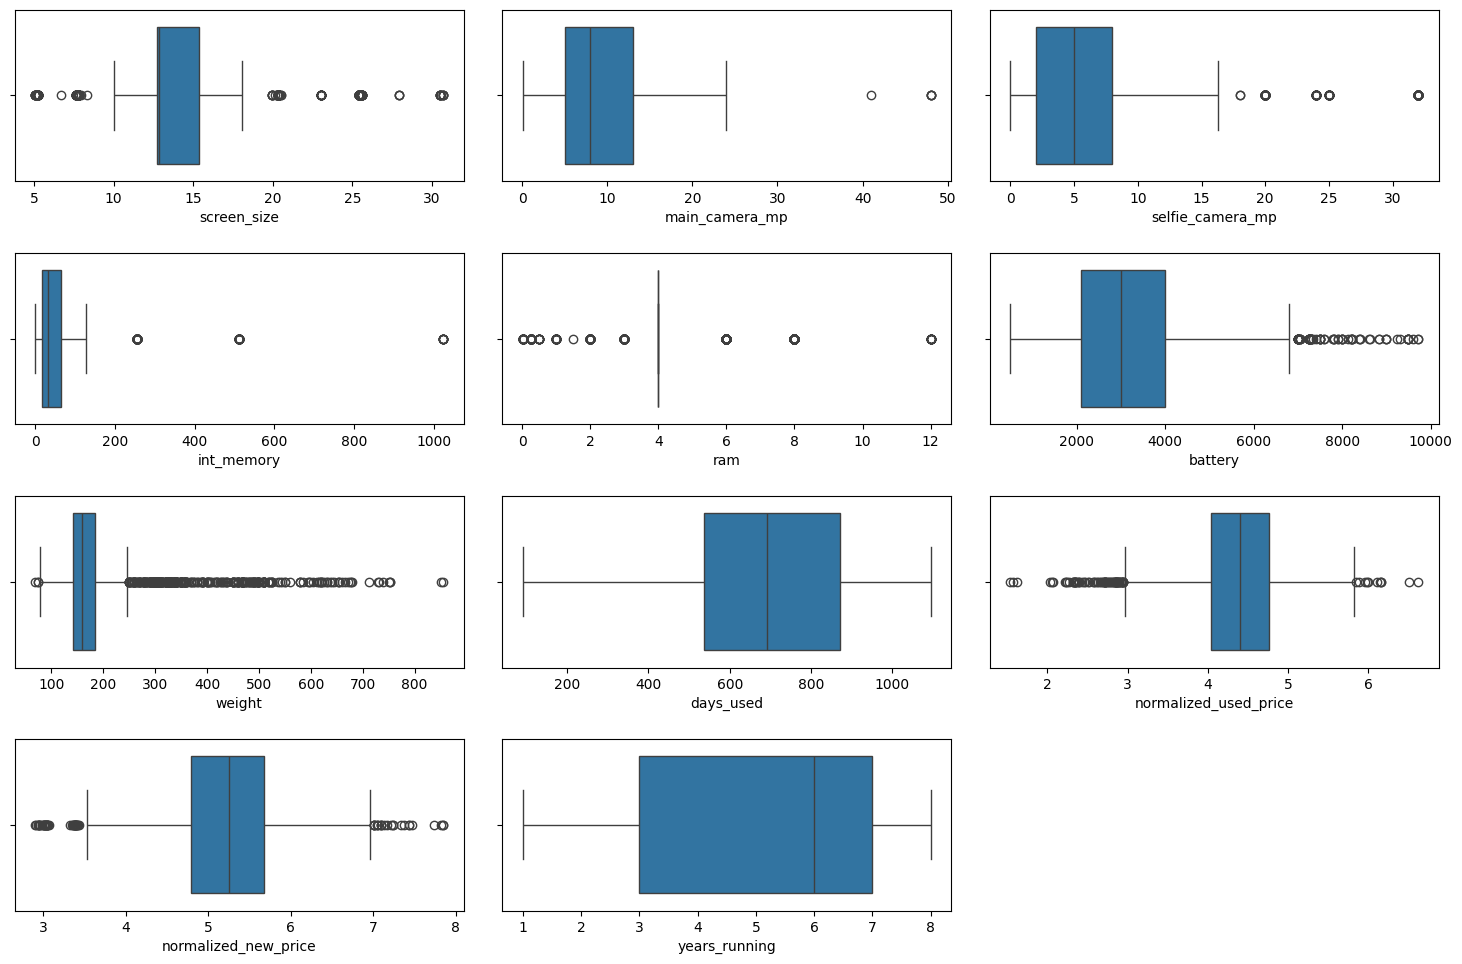

                  col    n    min      q1  median      q3     max  n_low  n_high
          screen_size 3444   5.08   12.70   12.83   15.34   30.71    198     252
       main_camera_mp 3444   0.08    5.00    8.00   13.00   48.00      0       5
     selfie_camera_mp 3444   0.00    2.00    5.00    8.00   32.00      0     221
           int_memory 3444   0.01   16.00   32.00   64.00 1024.00      0     138
                  ram 3444   0.02    4.00    4.00    4.00   12.00    325     302
              battery 3444 500.00 2100.00 3000.00 4000.00 9720.00      0      77
               weight 3444  69.00  142.00  160.00  185.00  855.00      3     365
            days_used 3444  91.00  537.75  691.00  870.00 1094.00      0       0
normalized_used_price 3444   1.54    4.03    4.41    4.76    6.62     74      11
 normalized_new_price 3444   2.90    4.79    5.25    5.67    7.85     42      24
        years_running 3444   1.00    3.00    6.00    7.00    8.00      0       0


In [407]:
#C86 outlier detection using boxplot
num_cols = df.select_dtypes(include=np.number).columns.tolist()
fig, axes = plt.subplots(4, 3, figsize=(15, 10))

for i, variable in enumerate(num_cols):
    sns.boxplot(data=df, x=variable, ax=axes.flat[i])

for j in range(len(num_cols), axes.size):
    axes.flat[j].set_visible(False)

fig.tight_layout(pad=2)
fig.savefig(
    "/content/drive/My Drive/Colab Notebooks/plots/C86_numeric_boxplots.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

rows = []
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    n = int(s.count())
    n_low = int((s < lo).sum())
    n_high = int((s > hi).sum())
    rec = {}
    rec["col"] = col
    rec["n"] = n
    rec["min"] = s.min()
    rec["q1"] = q1
    rec["median"] = s.median()
    rec["q3"] = q3
    rec["max"] = s.max()
    rec["n_low"] = n_low
    rec["n_high"] = n_high
    rows.append(rec)

tbl = pd.DataFrame(rows)
tbl = tbl.round(2)
print(tbl.to_string(index=False))

#### treat the field **battery** for outliers

n 3444
min 500.0
q1 2100.0
median 3000.0
q3 4000.0
max 9720.0
fence_lo -750.0
fence_hi 6850.0
n_low 0
n_high 77


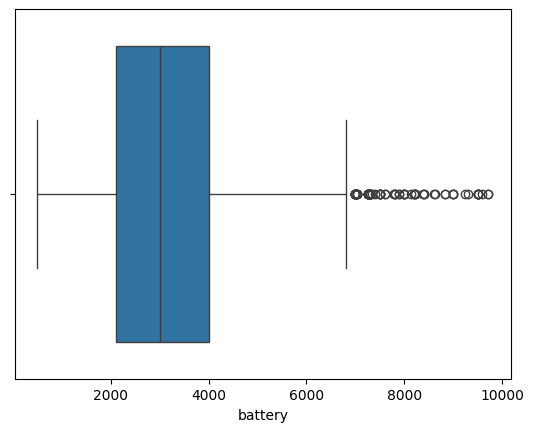

In [408]:
# C87 We use log transformation on skewed data.
# Log transformation reduces the skewness of data and tries to make it normal.
# Log transformation doesn’t always make it normal, sometimes makes data more skewed.
# It depends on the data. We have to apply transformation and control the result.
sns.boxplot(x=df["battery"]);

OUT = Path("/content/drive/My Drive/Colab Notebooks/plots")
plt.savefig(OUT / "C87_battery_outlier_detection.png", dpi=150, bbox_inches="tight")

s = df["battery"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

In [409]:
#C88 implent log transformation
df["battery"] = np.log(df["battery"])

n 3444
min 6.214608098422191
q1 7.649692623711514
median 8.006367567650246
q3 8.294049640102028
max 9.181940897454485
fence_lo 6.6831570991257445
fence_hi 9.260585164687797
n_low 4
n_high 0


3054    6.214608
888     6.429719
522     6.620073
521     6.620073
n_low 4


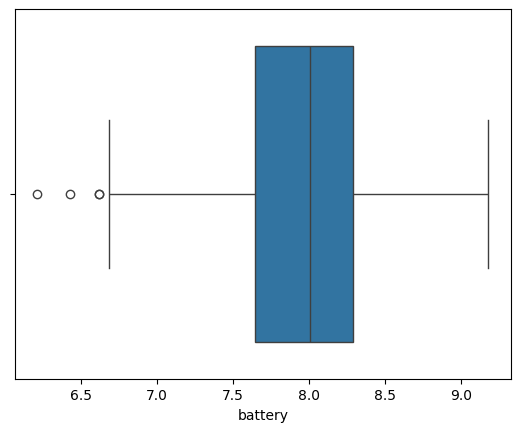

In [410]:
#C89 review and compare
sns.boxplot(x=df["battery"]);

OUT = Path("/content/drive/My Drive/Colab Notebooks/plots")
plt.savefig(OUT / "C89_battery_Xform.png", dpi=150, bbox_inches="tight")



s = df["battery"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)
print("")
print("")
print(s[s < lo].sort_values().to_string())
print("n_low", int((s < lo).sum()))

#### treat the field **weight** for outliers

n 3444
min 69.0
q1 142.0
median 160.0
q3 185.0
max 855.0
fence_lo 77.5
fence_hi 249.5
n_low 3
n_high 365


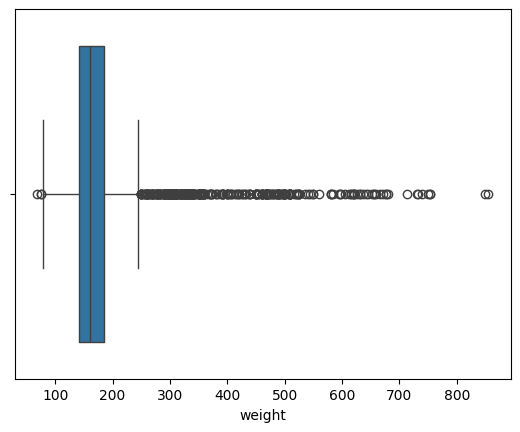

In [411]:
#C90
# Detect skewed data in weight.
sns.boxplot(x=df["weight"]);

s = df["weight"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)


In [412]:
#91 implent log transformation
df["weight"] = np.log(df["weight"])

weight
n 3444
min 4.23410650459726
q1 4.955827057601261
median 5.075173815233827
q3 5.220355825078324
max 6.75110146893676
fence_lo 4.5590339063856655
fence_hi 5.61714897629392
n_low 56
n_high 335


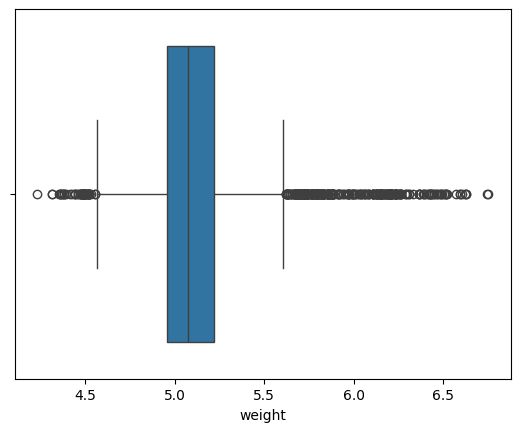

In [413]:
#C92 review and compare
sns.boxplot(x=df["weight"]);

s = df["weight"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ("weight")
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

#### treat the field **screen_size** for outliers
 450 screens winsorized to the interquartile range (IQR) fences. Rows and values rewritten.

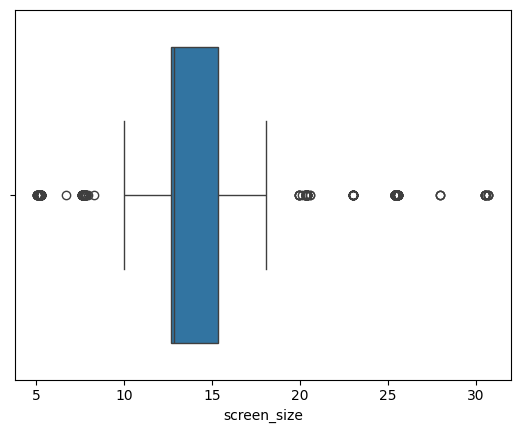

screen_size
n 3444
min 5.08
q1 12.7
median 12.83
q3 15.34
max 30.71
fence_lo 8.739999999999998
fence_hi 19.3
n_low 198
n_high 252


In [414]:
#C93
# visualizing the column prior outlier treatment
sns.boxplot(data=df,x='screen_size')
plt.show()

s = df["screen_size"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ("screen_size")
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)


In [415]:
#C94 treatment
#450 screens winsorized to the interquartile range (IQR) fences. Rows kept; values rewritten.
df = treat_outliers(df,'screen_size')

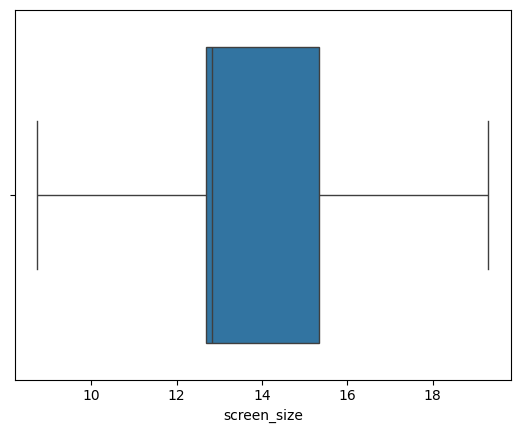

screen_size
n 3444
min 8.739999999999998
q1 12.7
median 12.83
q3 15.34
max 19.3
fence_lo 8.739999999999998
fence_hi 19.3
n_low 0
n_high 0


In [416]:
#C95
# visualizing the column after outlier treatment
sns.boxplot(data=df,x='screen_size')
plt.show()

s = df["screen_size"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ("screen_size")
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

#### treat the field **main_camera_mp** for outliers
 five high-MP devices winsorized to 25 MP.

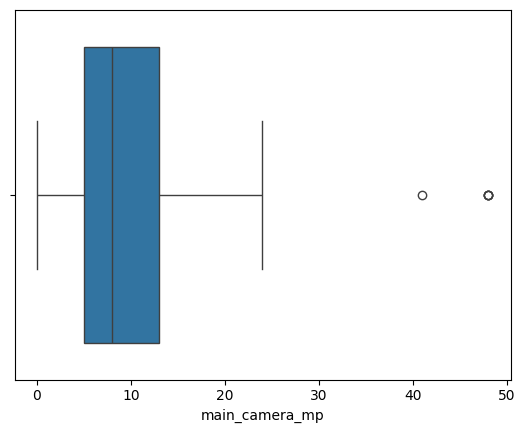

main_camera_mp
n 3444
min 0.08
q1 5.0
median 8.0
q3 13.0
max 48.0
fence_lo -7.0
fence_hi 25.0
n_low 0
n_high 5


In [417]:
#C96 visualizing the column prior outlier treatment
sns.boxplot(data=df,x='main_camera_mp')
plt.show()

s = df["main_camera_mp"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ("main_camera_mp")
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

In [418]:
#C97 treatment
df = treat_outliers(df,'main_camera_mp')



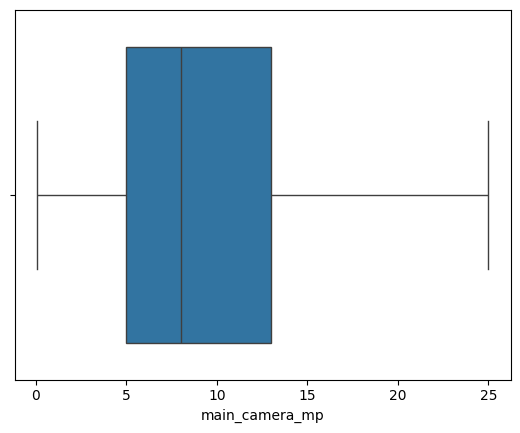

main_camera_mp
n 3444
min 0.08
q1 5.0
median 8.0
q3 13.0
max 25.0
fence_lo -7.0
fence_hi 25.0
n_low 0
n_high 0


In [419]:
#C98 visualizing the column after outlier treatment
sns.boxplot(data=df,x='main_camera_mp')
plt.show()

s = df["main_camera_mp"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ("main_camera_mp")
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

#### treat the field **selfie_camera_mp** for outliers

In [420]:
print(df[["selfie_camera_mp", "main_camera_mp"]].describe().to_string())
print("same column", df["selfie_camera_mp"].equals(df["main_camera_mp"]))

       selfie_camera_mp  main_camera_mp
count       3444.000000     3444.000000
mean           6.541580        9.590935
std            6.970849        4.578253
min            0.000000        0.080000
25%            2.000000        5.000000
50%            5.000000        8.000000
75%            8.000000       13.000000
max           32.000000       25.000000
same column False


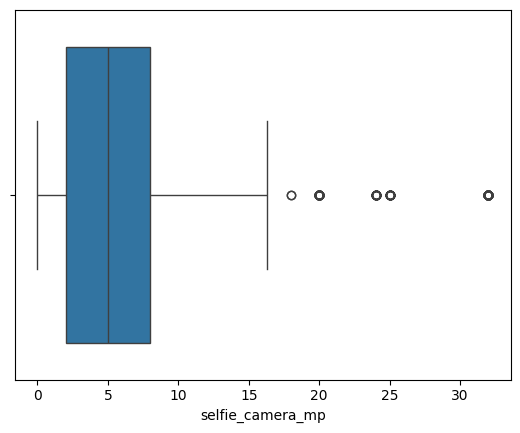

selfie_camera_mp
n 3444
min 0.0
q1 2.0
median 5.0
q3 8.0
max 32.0
fence_lo -7.0
fence_hi 17.0
n_low 0
n_high 221


In [421]:
#C99
# visualizing the column prior outlier treatment
sns.boxplot(data=df,x='selfie_camera_mp')
plt.show()

s = df["selfie_camera_mp"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ('selfie_camera_mp')
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

In [422]:
#C100 treatment
df = treat_outliers(df,'selfie_camera_mp')



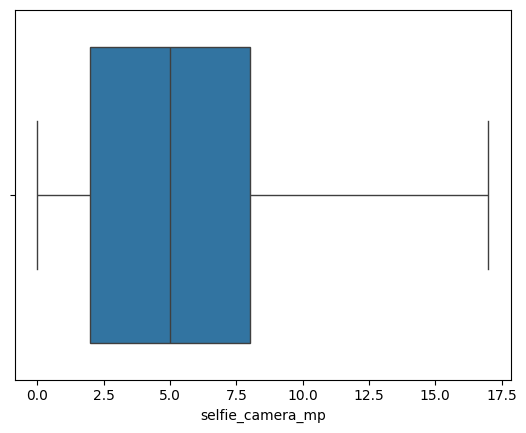

selfie_camera_mp
n 3444
min 0.0
q1 2.0
median 5.0
q3 8.0
max 17.0
fence_lo -7.0
fence_hi 17.0
n_low 0
n_high 0


In [423]:
#C101 visualizing the column after outlier treatment
# Yeilds 221 front cameras at 17 MP on the upper fence
sns.boxplot(data=df,x='selfie_camera_mp')
plt.show()

s = df["selfie_camera_mp"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ('selfie_camera_mp')
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

#### Decline treat for field **int_memory**

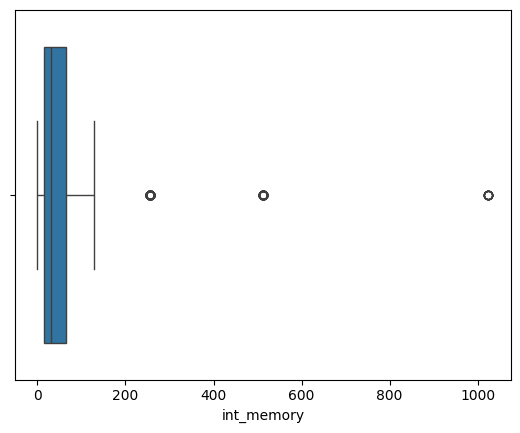

int_memory
n 3444
min 0.01
q1 16.0
median 32.0
q3 64.0
max 1024.0
fence_lo -56.0
fence_hi 136.0
n_low 0
n_high 138


In [424]:
#C102 visualizing the column prior outlier treatment
sns.boxplot(data=df,x='int_memory')
plt.show()

s = df["int_memory"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ('int_memory')
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)





In [425]:
#C103 Decline the clip
# Winsorize would turn every 256/512/1024 into 136 GB and leave 128 GB untouched.
# df = treat_outliers(df,'int_memory')

vc = df["int_memory"].value_counts()
vc = vc.sort_index()
print(vc.to_string())
print("n", int(df["int_memory"].count()))
print("n_above_fence", int((df["int_memory"] > 136).sum()))

int_memory
0.01          1
0.06         18
0.10         17
0.20          2
0.50          4
4.00         10
8.00         12
16.00      1287
24.00         1
32.00      1075
64.00       507
128.00      372
256.00       86
512.00       44
1024.00       8
n 3444
n_above_fence 138


#### treatment declines on  the field **ram** for outliers

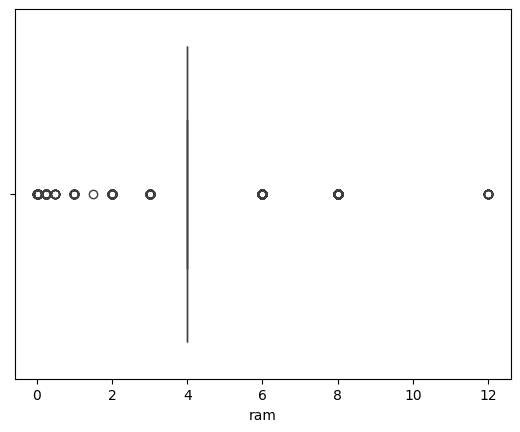

ram
n 3444
min 0.02
q1 4.0
median 4.0
q3 4.0
max 12.0
fence_lo 4.0
fence_hi 4.0
n_low 325
n_high 302


In [426]:
#C104 visualizing the column prior outlier treatment
sns.boxplot(data=df,x='ram')
plt.show()

s = df["ram"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ('ram')
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

In [427]:
#C105  decline treat_outliers on ram
# IQR is 0; clip would force every row to 4 GB

vc = df["ram"].value_counts()
vc = vc.sort_index()
print(vc.to_string())
print("n", int(df["ram"].count()))
print("n_above_fence", int((df["ram"] > 4).sum()))
print("n_below_fence", int((df["ram"] < 4).sum()))

ram
0.02       18
0.03       17
0.25       83
0.50        9
1.00       34
1.50        1
2.00       84
3.00       79
4.00     2817
6.00      154
8.00      130
12.00      18
n 3444
n_above_fence 302
n_below_fence 325


#### treat the field **normalized_used_price** for outliers

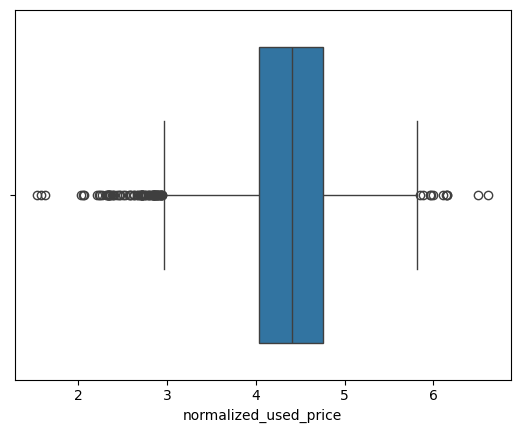

normalized_used_price
n 3444
min 1.536867219599265
q1 4.03339955011427
median 4.4050715472263064
q3 4.757934121490633
max 6.619433001642933
fence_lo 2.946597693049725
fence_hi 5.844735978555178
n_low 74
n_high 11


In [428]:
#C106 visualizing the column prior outlier treatment
sns.boxplot(data=df,x='normalized_used_price')
plt.show()

s = df["normalized_used_price"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ('normalized_used_price')
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

In [429]:
# C107 decline treat_outliers on normalized_used_price
# target; 74 low + 11 high are real cheap/expensive devices
print("n", 3444)
print("n_below_fence", 74)
print("n_above_fence", 11)

n 3444
n_below_fence 74
n_above_fence 11


#### treat the field **normalized_new_price** for outliers

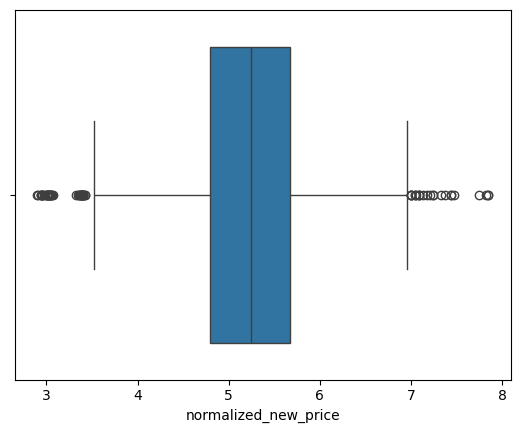

normalized_new_price
n 3444
min 2.9014215940827497
q1 4.790944107245906
median 5.24623428529058
q3 5.674731194367024
max 7.847840659422009
fence_lo 3.4652634765642287
fence_hi 7.000411825048701
n_low 42
n_high 24


In [430]:
#C108 visualizing the column prior outlier treatment
sns.boxplot(data=df,x='normalized_new_price')
plt.show()

s = df["normalized_new_price"].dropna()
q1 = s.quantile(0.25)
q3 = s.quantile(0.75)
iqr = q3 - q1
lo = q1 - 1.5 * iqr
hi = q3 + 1.5 * iqr
n = int(s.count())
n_low = int((s < lo).sum())
n_high = int((s > hi).sum())

print ('normalized_new_price')
print("n", n)
print("min", s.min())
print("q1", q1)
print("median", s.median())
print("q3", q3)
print("max", s.max())
print("fence_lo", lo)
print("fence_hi", hi)
print("n_low", n_low)
print("n_high", n_high)

### Dummy variables.
 categorical text cannot go into Ordinary Least Squares (OLS) as letters; dummy columns are 0/1 with no implied order;
 drop_first=True drops one level so the dummies are not a complete linear set.

In [431]:
#C109 drop_first=True will drop one of the three origin columns
df = pd.get_dummies(df, columns=["os", "4g", "5g"], drop_first=True)
df = df.astype({"os_Others": int, "os_Windows": int, "os_iOS": int, "4g_yes": int, "5g_yes": int})
print(df.head())
print(df.dtypes.to_string())

   screen_size  main_camera_mp  selfie_camera_mp  int_memory  ram   battery  \
0        14.50            13.0               5.0        64.0  3.0  8.013012   
1        17.30            13.0              16.0       128.0  8.0  8.366370   
2        16.69            13.0               8.0       128.0  8.0  8.342840   
3        19.30            13.0               8.0        64.0  6.0  8.888757   
4        15.32            13.0               8.0        64.0  3.0  8.517193   

     weight  days_used  normalized_used_price  normalized_new_price  \
0  4.983607        127               4.307572              4.715100   
1  5.361292        325               5.162097              5.519018   
2  5.361292        162               5.111084              5.884631   
3  6.173786        345               5.135387              5.630961   
4  5.220356        293               4.389995              4.947837   

   years_running  os_Others  os_Windows  os_iOS  4g_yes  5g_yes  
0              1          0     

## EDA
post-prep snapshot.
* n = 3,444 on every field.
* Intended treats are visible
* screen / both cameras: fences clean (n_high 0)
* memory: 138 high SKUs left
* RAM: 325 + 302, IQR still 0
* battery log: 4 low
* weight log: 56 + 335 still outside
* used / new price: declined tails
* 5g_yes = 152 (same small n as Q5G)
* OS leftovers: Others 137, Windows 67, iOS 36 — Android is the rest

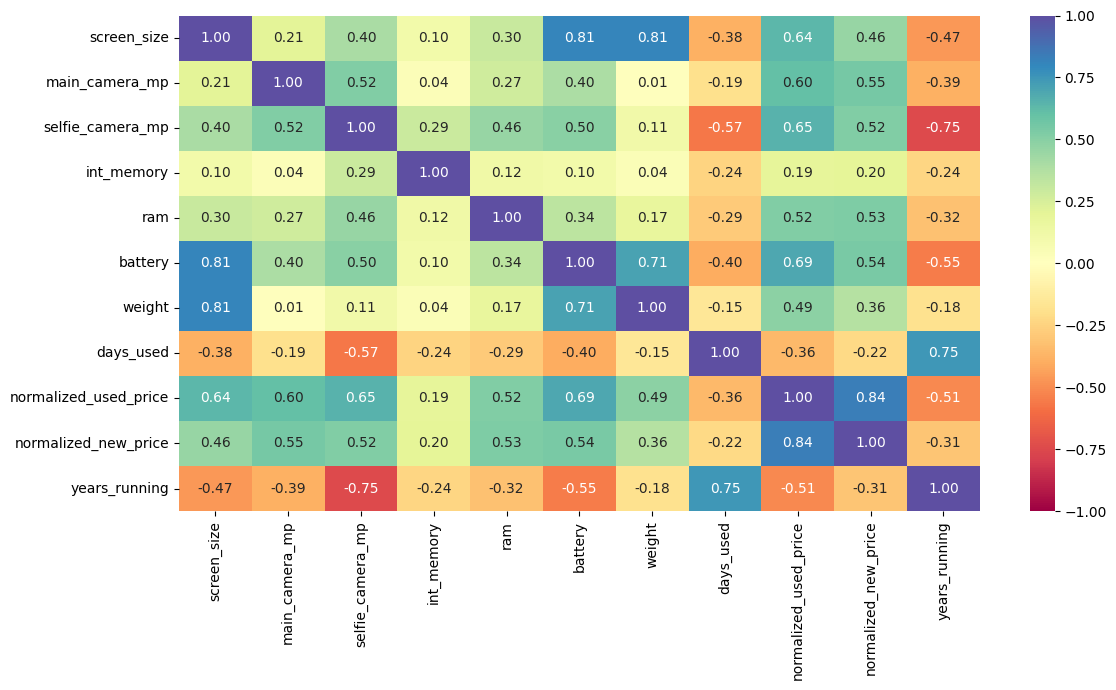

                       screen_size  main_camera_mp  selfie_camera_mp  int_memory   ram  battery  weight  days_used  normalized_used_price  normalized_new_price  years_running
screen_size                   1.00            0.21              0.40        0.10  0.30     0.81    0.81      -0.38                   0.64                  0.46          -0.47
main_camera_mp                0.21            1.00              0.52        0.04  0.27     0.40    0.01      -0.19                   0.60                  0.55          -0.39
selfie_camera_mp              0.40            0.52              1.00        0.29  0.46     0.50    0.11      -0.57                   0.65                  0.52          -0.75
int_memory                    0.10            0.04              0.29        1.00  0.12     0.10    0.04      -0.24                   0.19                  0.20          -0.24
ram                           0.30            0.27              0.46        0.12  1.00     0.34    0.17      -0.29           

In [432]:
#109 post-prep snapshot.
# n = 3,444 on every field.
# Intended treats are visible
# screen / both cameras: fences clean (n_high 0)
# memory: 138 high SKUs left
# RAM: 325 + 302, IQR still 0
# battery log: 4 low
# weight log: 56 + 335 still outside
# used / new price: declined tails
# 5g_yes = 152 (same small n as Q5G)
# OS leftovers: Others 137, Windows 67, iOS 36 — Android is the rest

import seaborn as sns

num_cols = [
    "screen_size",
    "main_camera_mp",
    "selfie_camera_mp",
    "int_memory",
    "ram",
    "battery",
    "weight",
    "days_used",
    "normalized_used_price",
    "normalized_new_price",
    "years_running",
]
corr = df[num_cols].corr()

plt.figure(figsize=(12, 7))
sns.heatmap(
    corr,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="Spectral",
)
plt.tight_layout()
plt.savefig(
    "/content/drive/My Drive/Colab Notebooks/plots/C109_heatmap.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
print(corr.round(2).to_string())

rows = []
num_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in num_cols:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    n = int(s.count())
    n_low = int((s < lo).sum())
    n_high = int((s > hi).sum())
    rec = {}
    rec["col"] = col
    rec["n"] = n
    rec["min"] = s.min()
    rec["q1"] = q1
    rec["median"] = s.median()
    rec["q3"] = q3
    rec["max"] = s.max()
    rec["n_low"] = n_low
    rec["n_high"] = n_high
    rows.append(rec)

tbl = pd.DataFrame(rows)
tbl = tbl.round(2)
print(tbl.to_string(index=False))

In [433]:
#C110
print ("****** The original ReCell dataset")
df_backup.describe(include='all').T

****** The original ReCell dataset


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
brand_name,3454,34,Others,502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
os,3454,4,Android,3214,NaN,NaN,NaN,NaN,NaN,NaN,NaN
screen_size,3454.0,NaN,NaN,NaN,13.713115,3.80528,5.08,12.7,12.83,15.34,30.71
4g,3454,2,yes,2335,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5g,3454,2,no,3302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
main_camera_mp,3275.0,NaN,NaN,NaN,9.460208,4.815461,0.08,5.0,8.0,13.0,48.0
selfie_camera_mp,3452.0,NaN,NaN,NaN,6.554229,6.970372,0.0,2.0,5.0,8.0,32.0
int_memory,3450.0,NaN,NaN,NaN,54.573099,84.972371,0.01,16.0,32.0,64.0,1024.0
ram,3450.0,NaN,NaN,NaN,4.036122,1.365105,0.02,4.0,4.0,4.0,12.0
battery,3448.0,NaN,NaN,NaN,3133.402697,1299.682844,500.0,2100.0,3000.0,4000.0,9720.0


In [434]:
#C111
print ("****** The modified reCell dataset")
df.describe(include='all').T

****** The modified reCell dataset


,count,mean,std,min,25%,50%,75%,max
screen_size,3444.0,13.545195,2.808738,8.740000,12.700000,12.830000,15.340000,19.300000
main_camera_mp,3444.0,9.590935,4.578253,0.080000,5.000000,8.000000,13.000000,25.000000
selfie_camera_mp,3444.0,5.947213,5.342043,0.000000,2.000000,5.000000,8.000000,17.000000
int_memory,3444.0,54.575258,85.049276,0.010000,16.000000,32.000000,64.000000,1024.000000
ram,3444.0,4.040250,1.363412,0.020000,4.000000,4.000000,4.000000,12.000000
battery,3444.0,7.967655,0.404038,6.214608,7.649693,8.006368,8.294050,9.181941
weight,3444.0,5.135639,0.342674,4.234107,4.955827,5.075174,5.220356,6.751101
days_used,3444.0,675.919570,248.112174,91.000000,537.750000,691.000000,870.000000,1094.000000
normalized_used_price,3444.0,4.364635,0.589742,1.536867,4.033400,4.405072,4.757934,6.619433
normalized_new_price,3444.0,5.234784,0.683885,2.901422,4.790944,5.246234,5.674731,7.847841


##Observations

- 10 Infinix rows dropped; n = 3,444; missing total = 0
- years_running = 2021 − release_year; release_year dropped (collinear pair)
- brand_name dropped (dummy / cardinality)
- battery and weight: log transform (units changed)
- screen_size, main_camera_mp, selfie_camera_mp: IQR winsorize
- ram, int_memory, normalized_used_price, normalized_new_price: decline clip
- years_running and days_used compete; first OLS uses one

##Data Prepatation for Modeling
- We want to develop a dynamic pricing strategy for used and refurbished devices
- We want to predict the price of a used phone/tablet
- We want to identify factors that significantly influence retail price.

- Before we proceed to build a model, we'll have to encode categorical features
- We'll split the data into train and test to be able to evaluate the model that we build on the train data
- We will build a Linear Regression model using the train data and then check it's performance

In [435]:
# C112 X = predictors (independent). y = used price (dependent / target)
X = df.drop(["normalized_used_price"], axis=1)  # predictors (independent)
y = df["normalized_used_price"]                 # target (dependent)

print(X.head())
print(y.head())

   screen_size  main_camera_mp  selfie_camera_mp  int_memory  ram   battery  \
0        14.50            13.0               5.0        64.0  3.0  8.013012   
1        17.30            13.0              16.0       128.0  8.0  8.366370   
2        16.69            13.0               8.0       128.0  8.0  8.342840   
3        19.30            13.0               8.0        64.0  6.0  8.888757   
4        15.32            13.0               8.0        64.0  3.0  8.517193   

     weight  days_used  normalized_new_price  years_running  os_Others  \
0  4.983607        127              4.715100              1          0   
1  5.361292        325              5.519018              1          0   
2  5.361292        162              5.884631              1          0   
3  6.173786        345              5.630961              1          0   
4  5.220356        293              4.947837              1          0   

   os_Windows  os_iOS  4g_yes  5g_yes  
0           0       0       1       0  


In [436]:
#C113 add the intercept to data
X = sm.add_constant(X)
print(X.head())

   const  screen_size  main_camera_mp  selfie_camera_mp  int_memory  ram  \
0    1.0        14.50            13.0               5.0        64.0  3.0   
1    1.0        17.30            13.0              16.0       128.0  8.0   
2    1.0        16.69            13.0               8.0       128.0  8.0   
3    1.0        19.30            13.0               8.0        64.0  6.0   
4    1.0        15.32            13.0               8.0        64.0  3.0   

    battery    weight  days_used  normalized_new_price  years_running  \
0  8.013012  4.983607        127              4.715100              1   
1  8.366370  5.361292        325              5.519018              1   
2  8.342840  5.361292        162              5.884631              1   
3  8.888757  6.173786        345              5.630961              1   
4  8.517193  5.220356        293              4.947837              1   

   os_Others  os_Windows  os_iOS  4g_yes  5g_yes  
0          0           0       0       1       0  
1 

In [437]:
#C114 splitting the data in 70:30 ratio for train to test data

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)
print("train rows", x_train.shape[0])
print("test rows", x_test.shape[0])

train rows 2410
test rows 1034


## Model Building - Linear Regression

In [438]:
#C115
olsmodel = sm.OLS(y_train, x_train).fit()
print(olsmodel.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.847
Model:                               OLS   Adj. R-squared:                  0.846
Method:                    Least Squares   F-statistic:                     881.1
Date:                   Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                           15:29:08   Log-Likelihood:                 87.074
No. Observations:                   2410   AIC:                            -142.1
Df Residuals:                       2394   BIC:                            -49.55
Df Model:                             15                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

## Interpetation of R-squared p and coefficient

### Interpretation of p-values (P > |t|)

On this initial fit, p > 0.05 for battery, days_used, int_memory, os_iOS, and 5g_yes.
That is fail-to-reject of “slope = 0,” not proof the predictor is useless.
screen_size is significant (p ≈ 0). p-values will change after VIF.

###Adjusted. R-squared
Adj. R-squared is 0.846 on the training set. R-squared is 0.847.
The two are close because n is large relative to 15 predictors.
This is train only. Test comes later.

###const coefficient
const is the intercept (b0) = 0.0604 on this fit (p = 0.715).
It is the predicted normalized used price when every predictor is 0.
That point is not a real device. Do not treat 0.0604 as a list price.

###Coefficient of a predictor variable
The coefficient is the change in predicted used price for a 1-unit change in that predictor, holding the other terms fixed.

normalized_new_price = 0.4146 (p ≈ 0).
Holding the other predictors fixed, a 1-unit higher normalized new price goes with about 0.41 higher normalized used price.
That is the driver.

## Model Performance Check

In [439]:
#C116 checking model performance on train set (seen 70% data)
print("Training Performance\n")
olsmodel_train_perf = model_performance_regression(olsmodel, x_train, y_train)
olsmodel_train_perf

Training Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.233384,0.180719,0.846642,0.845617,4.363844


In [440]:
#C117 checking model performance on train set (seen 30% data)
print("Testing Performance\n")
olsmodel_test_perf = model_performance_regression(olsmodel, x_test, y_test)
olsmodel_test_perf

Testing Performance



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,0.228809,0.179317,0.841477,0.838983,4.276517


Train and test R² are close (0.847 vs 0.841). The fit generalizes.
VIF still required before we trust battery vs weight vs years_running.

Observations
- Train R² = 0.847. The line is not underfitting on the 70%.
- Train vs test RMSE (0.233 vs 0.229) and MAE (0.181 vs 0.179) are close.
  Test R² = 0.841. The line is not falling apart on the unseen 30%.
- MAE ≈ 0.18 on test is the typical miss in normalized used-price units.
- MAPE ≈ 4.3% on test is the typical miss relative to used price, not new price.
- Good scores do not clear battery vs weight or years_running vs days_used.
  Variance Inflation Factor (VIF) is next.

## Checking Linear Regression Assumptions

- In order to make statistical inferences from a linear regression model, it is important to ensure that the assumptions of linear regression are satisfied.

####Test for Multicollinearity
* There are different ways of detecting (or testing) multicollinearity. One such way is Variation Inflation Factor.

* **Variance  Inflation  factor**:  Variance  inflation  factors  measure  the  inflation  in  the variances of the regression coefficients estimates due to collinearities that exist among the  predictors.  It  is  a  measure  of  how  much  the  variance  of  the  estimated  regression coefficient $\beta_k$ is "inflated" by  the  existence  of  correlation  among  the  predictor variables in the model.

* **General Rule of Thumb**:

    - If VIF is 1, then there is no correlation among the $k$th predictor and the remaining predictor variables, and  hence, the variance of $\beta_k$ is not inflated at all.
    - If VIF exceeds 5, we say there is moderate VIF
    - if it is 10 or exceeding 10, it shows signs of high multi-collinearity.
    - The purpose of the analysis should dictate which threshold to use.

In [441]:
#C118
checking_vif(x_train)

,feature,VIF
0,const,1.000000
1,screen_size,5.420404
2,main_camera_mp,2.186583
3,selfie_camera_mp,3.438259
4,int_memory,1.242753
5,ram,2.089840
6,battery,5.030358
7,weight,4.721672
8,days_used,2.464842
9,normalized_new_price,2.786175


In [442]:
#C118
high_vif_columns = ["screen_size"]
df_tmp = treating_multicollinearity(x_train, y_train, high_vif_columns)
print(df_tmp.to_string(index=False))

        col  Adj. R-squared after_dropping col  RMSE after dropping col
screen_size                           0.842448                 0.236604


####Evaluation

Screen size has moderate colinearity we should drop it

In [443]:
#C119
x_train = x_train.drop(columns=["screen_size"])
x_test = x_test.drop(columns=["screen_size"])
olsmodel = sm.OLS(y_train, x_train).fit()
print(olsmodel.summary())
print(checking_vif(x_train).to_string(index=False))

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.843
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     921.1
Date:                   Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                           15:29:09   Log-Likelihood:                 61.581
No. Observations:                   2410   AIC:                            -93.16
Df Residuals:                       2395   BIC:                            -6.351
Df Model:                             14                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

####check if multicollinearity is still present in the data.
All varibles are below 5 with the exception of const. We have no multi colinearity

Time to review the model!

In [444]:
#C120
olsmod1 = sm.OLS(y_train, x_train).fit()
print(olsmod1.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.843
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     921.1
Date:                   Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                           15:29:09   Log-Likelihood:                 61.581
No. Observations:                   2410   AIC:                            -93.16
Df Residuals:                       2395   BIC:                            -6.351
Df Model:                             14                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

### the p-values of the coefficients have become reliable and we can remove the non-significant predictor variables.
They are :
1. os_iOS
2. os_Others
3. 5g_yes
4. days_used
5. const

In [445]:
#C121 initial list of columns

x_train2 = x_train.copy()
x_test2 = x_test.copy()
cols = x_train2.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    x_train_aux = x_train2[cols]

    # fitting the model
    model = sm.OLS(y_train, x_train_aux).fit()

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'main_camera_mp', 'selfie_camera_mp', 'ram', 'weight', 'normalized_new_price', 'years_running', 'os_Others', '4g_yes']


In [446]:
#C122
x_train3 = x_train2[selected_features]
x_test3 = x_test2[selected_features]
olsmod2 = sm.OLS(y_train, x_train3).fit()
print(olsmod2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.843
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     1608.
Date:                   Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                           15:29:09   Log-Likelihood:                 56.726
No. Observations:                   2410   AIC:                            -95.45
Df Residuals:                       2401   BIC:                            -43.36
Df Model:                              8                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

###Test for Linearity and independence

In [447]:
#123 let us create a dataframe with actual, fitted and residual values
df_pred = pd.DataFrame()

df_pred["Actual Values"] = y_train  # actual values
df_pred["Fitted Values"] = olsmod2.fittedvalues  # predicted values
df_pred["Residuals"] = olsmod2.resid  # residuals

df_pred.head()

,Actual Values,Fitted Values,Residuals
1387,4.034241,4.154601,-0.120360
2652,4.487062,4.768074,-0.281011
683,4.029095,4.203609,-0.174515
1453,4.004237,3.872102,0.132135
3323,4.558288,4.566031,-0.007743


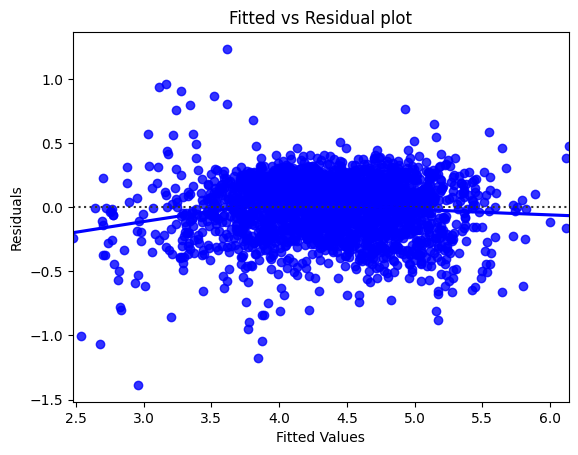

In [448]:
#C124 let's plot the fitted values vs residuals

sns.residplot(
    data=df_pred, x="Fitted Values", y="Residuals", color="blue", lowess=True
)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Fitted vs Residual plot")
plt.show()

**Observations**
Residuals vs fitted: no strong curve in the main mass (fitted ~3.5–5.5).
Slight over-prediction on the cheapest phones.
Linearity and independence acceptable for olsmod2.

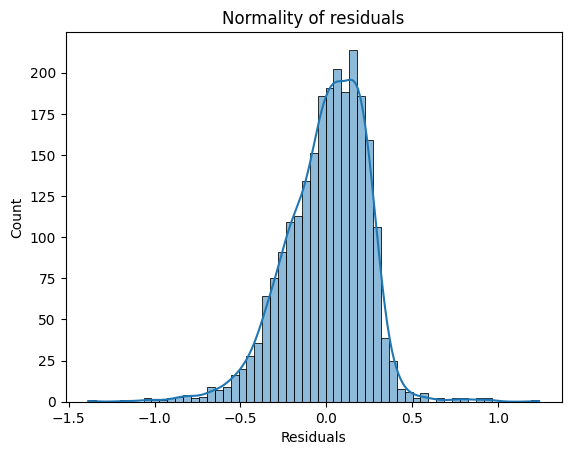

In [449]:
#C124 TEST FOR NORMALITY
# Error terms/residuals should be normally distributed.
sns.histplot(data=df_pred, x="Residuals", kde=True)
plt.title("Normality of residuals")
plt.show()

**Observations**
Residuals are mound-shaped with a longer left tail.
Not perfect normal (JB rejects at this n). Good enough for olsmod2.

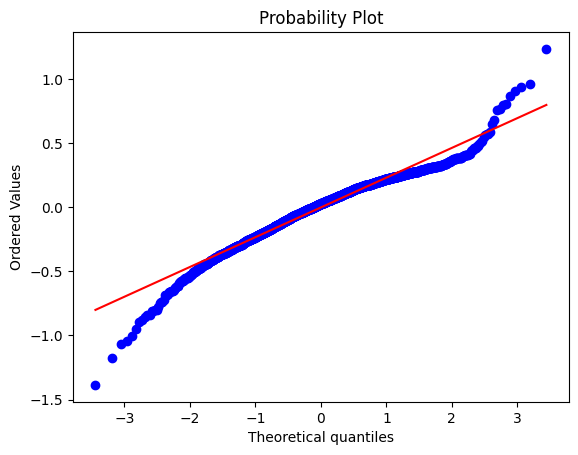

In [450]:
#C125 The QQ plot of residuals can be used to visually check the normality assumption.
# The normal probability plot of residuals should approximately follow a straight line.
import pylab
import scipy.stats as stats

stats.probplot(df_pred["Residuals"], dist="norm", plot=pylab)
plt.show()

**Observations**
Q-Q: center tracks the line. Tails peel off, left more than right.
Same cheap-phone tail as the residual histogram. Usable for olsmod2.

In [451]:
#C126 The Shapiro-Wilk test can also be used for checking the normality. The null and alternate hypotheses of the test are as follows:
# Null hypothesis - Data is normally distributed.
# Alternate hypothesis - Data is NOT normally distributed.
stats.shapiro(df_pred["Residuals"])

ShapiroResult(statistic=np.float64(0.9657418620205672), pvalue=np.float64(1.6903417845540642e-23))

**Observations**
Since p-value < 0.05, Shapiro rejects normality.
Strictly speaking, the residuals are not normal.
Fail-to-reject is not available here; reject is not “throw the model out.”

In [452]:
###C127 TEST FOR HOMOSCEDASTICITY
#Homoscedacity** - If the variance of the residuals are symmetrically distributed across the regression line , then the data is said to homoscedastic.
#Heteroscedacity** - If the variance is unequal for the residuals across the regression line, then the data is said to be heteroscedastic. In this case the residuals can form an arrow shape or any other non symmetrical shape.
import statsmodels.stats.api as sms
from statsmodels.compat import lzip

name = ["F statistic", "p-value"]
# test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train3)
# lzip(name, test)

test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train3)
print(test)
print("F statistic", test[0])
print("p-value", test[1])

(np.float64(1.0846236961167481), np.float64(0.08013484219980352), 'increasing')
F statistic 1.0846236961167481
p-value 0.08013484219980352


/tmp/ipykernel_1420/3054551614.py:11: FutureWarning: het_goldfeldquandt currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a GoldfeldQuandtResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  test = sms.het_goldfeldquandt(df_pred["Residuals"], x_train3)


Goldfeld–Quandt p = 0.080 (> 0.05).
Fail-to-reject homoscedasticity. No evidence of a funnel.
Not proof the variance is perfectly equal.

In [453]:
#C128 Assumptions are acceptable for this project. Normality fails in the tails.
print(olsmod2.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.843
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     1608.
Date:                   Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                           15:29:10   Log-Likelihood:                 56.726
No. Observations:                   2410   AIC:                            -95.45
Df Residuals:                       2401   BIC:                            -43.36
Df Model:                              8                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

Observations
- Train R² = 0.843, Adj. R² = 0.842. The line accounts for about 84% of train used-price variation.
- Driver: +1 normalized new price → about +0.41 normalized used price, others fixed.
- Size: +1 log(gram) of weight → about +0.46 used price. Battery is not in the final model.
- Age: +1 year running → about −0.018 used price.
- Rear camera +0.022 and selfie +0.020 per clipped MP.
- RAM +0.025 per GB (the phones that are not 4 GB).
- 4G vs no: +0.045. os_Others vs Android: −0.088.
- const = −0.51 is not a list price.
- Test scores still needed on x_test3 before calling this the production number.




## Final Model

In [454]:
#C128.5 let's check the model parameters
olsmod2.params

,0
const,-0.507630
main_camera_mp,0.021662
selfie_camera_mp,0.019940
ram,0.024921
weight,0.457251
normalized_new_price,0.413303
years_running,-0.018299
os_Others,-0.087451
4g_yes,0.044630


In [455]:
#C129 Let us write the equation of linear regression
Equation = "normalized_used_price ="
print(Equation, end=" ")
for i in range(len(x_train3.columns)):
    if i == 0:
        print(olsmod2.params[i], "+", end=" ")
    elif i != len(x_train3.columns) - 1:
        print(
            olsmod2.params[i],
            "* (",
            x_train3.columns[i],
            ")",
            "+",
            end="  ",
        )
    else:
        print(olsmod2.params[i], "* (", x_train3.columns[i], ")")

normalized_used_price = -0.5076295698404162 + 0.021661986799150667 * ( main_camera_mp ) +  0.019940132107082797 * ( selfie_camera_mp ) +  0.02492126968051294 * ( ram ) +  0.4572506708882924 * ( weight ) +  0.4133025869421437 * ( normalized_new_price ) +  -0.018298521002028233 * ( years_running ) +  -0.0874507612904615 * ( os_Others ) +  0.044630419775566116 * ( 4g_yes )


/tmp/ipykernel_1420/515557111.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsmod2.params[i], "+", end=" ")
/tmp/ipykernel_1420/515557111.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  olsmod2.params[i],
/tmp/ipykernel_1420/515557111.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(olsmod2.params[i], "* (", x_train3.columns[i], ")")


normalized_used_price
  = -0.508
  + 0.413 * normalized_new_price
  + 0.457 * weight
  + 0.022 * main_camera_mp
  + 0.020 * selfie_camera_mp
  + 0.025 * ram
  - 0.018 * years_running
  - 0.087 * os_Others
  + 0.045 * 4g_yes

weight is log(grams). Cameras are clipped MP.

In [456]:
#130 predictions on the test set
pred = olsmod2.predict(x_test3)

df_pred_test = pd.DataFrame({"Actual": y_test, "Predicted": pred})
df_pred_test.sample(10, random_state=1)

,Actual,Predicted
2274,4.033887,4.125585
3014,3.653770,3.908029
517,4.536249,4.786364
1678,4.474492,4.426702
774,4.252203,4.427794
2977,3.958907,3.960173
751,4.529476,4.681675
3422,5.069219,4.786933
2741,4.566117,4.410676
3343,5.327536,5.446364


In [457]:
#C131
print(model_performance_regression(olsmod2, x_train3, y_train).to_string(index=False))
print("")
print(model_performance_regression(olsmod2, x_test3, y_test).to_string(index=False))

    RMSE      MAE  R-squared  Adj. R-squared     MAPE
0.236342 0.183081   0.842731        0.842141 4.425279

    RMSE      MAE  R-squared  Adj. R-squared     MAPE
0.232026 0.181627   0.836988        0.835556 4.336189


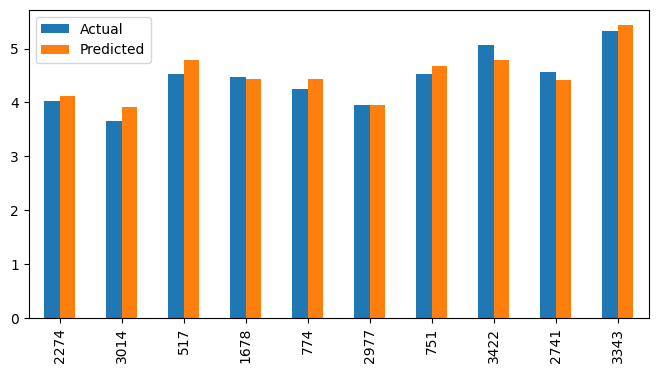

In [458]:
#C131
df_tmp = df_pred_test.sample(10, random_state=1)
df_tmp.plot(kind="bar", figsize=(8, 4))
plt.show()

In [459]:
#C132 the final model
olsmodel_final = sm.OLS(y_train, x_train3).fit()
print(olsmodel_final.summary())

                              OLS Regression Results                             
Dep. Variable:     normalized_used_price   R-squared:                       0.843
Model:                               OLS   Adj. R-squared:                  0.842
Method:                    Least Squares   F-statistic:                     1608.
Date:                   Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                           15:29:10   Log-Likelihood:                 56.726
No. Observations:                   2410   AIC:                            -95.45
Df Residuals:                       2401   BIC:                            -43.36
Df Model:                              8                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

In [460]:
#C133 checking model performance on train set (seen 70% data)
print("Train results...")
olsmod2_train_perf = model_performance_regression(olsmodel_final, x_train3, y_train)
print(olsmod2_train_perf.to_string(index=False))

Train results...
    RMSE      MAE  R-squared  Adj. R-squared     MAPE
0.236342 0.183081   0.842731        0.842141 4.425279


In [461]:
#C134 checking model performance on test set (unseen 30% data)
print("Test results...")
olsmod2_test_perf = model_performance_regression(olsmodel_final, x_test3, y_test)
print(olsmod2_test_perf.to_string(index=False))

Test results...
    RMSE      MAE  R-squared  Adj. R-squared     MAPE
0.232026 0.181627   0.836988        0.835556 4.336189


In [462]:
#C135 predicted normalized used price on test.

pred = olsmodel_final.predict(x_test3)
tbl = pd.DataFrame()
tbl["normalized_used_price"] = y_test
tbl["normalized_used_price_pred"] = pred
tbl["error"] = tbl["normalized_used_price"] - tbl["normalized_used_price_pred"]
print(tbl.head().to_string())

      normalized_used_price  normalized_used_price_pred     error
1012               4.484922                    4.181226  0.303695
321                3.988243                    3.957813  0.030430
2731               4.365008                    4.632218 -0.267210
2893               3.660737                    3.754889 -0.094152
102                2.989714                    3.115947 -0.126232


## Actionable Insights and Recommendations

Final model: olsmodel_final on 3,444 devices (10 Infinix rows dropped).
Train R² = 0.843. Test R² = 0.837. Test MAE = 0.182. Test MAPE ≈ 4.3% of used price.
Train and test RMSE/MAE are close. The line generalizes. That is not 83% “accuracy.”

Equation (current units)
normalized_used_price
  ≈ -0.508
  + 0.413 * normalized_new_price
  + 0.457 * weight            # log(grams)
  + 0.022 * main_camera_mp    # clipped MP
  + 0.020 * selfie_camera_mp
  + 0.025 * ram
  - 0.018 * years_running
  - 0.087 * os_Others         # vs Android
  + 0.045 * 4g_yes            # vs no 4G

What moves used price
1. New price is the driver. A higher original tier still sells higher used.
2. Size shows up as log-weight, not battery. Battery was dropped after it fought weight (r ≈ 0.81).
3. Older devices sell lower: about −0.018 per year running.
4. 4G vs no 4G: +0.045. That is not “4G or better.” 5G was dropped (n = 152, p > 0.05).
5. Better cameras (clipped MP) and extra RAM (phones not stuck at 4 GB) add a little.
6. Non-Android “Others” sell a bit lower than Android, others fixed.

What we did not keep
- screen_size: Variance Inflation Factor (VIF) treat; fit barely moved
- battery, days_used, int_memory, 5g_yes, os_iOS, os_Windows: p-loop
- Do not talk grams or mAh in the coefficients. Weight is log(grams).

Caveats
- Shapiro/Q-Q: residual tails, especially cheap phones. Coefficients still usable at n = 2,410.
- Goldfeld–Quandt p = 0.080: fail-to-reject equal variance. Not proof variance is flat.
- const is not a list price.
- Pricing: use new-price tier, age, 4G, and size. Do not build a story on battery or 5G from this model.

#Export to HTML

In [463]:
# from google.colab import files
# f = files.upload()

# # Convert ipynb to html
# import subprocess
# file0 = list(f.keys())[0]
# _ = subprocess.run(["pip", "install", "nbconvert"])
# _ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# # download the html
# files.download(file0[:-5]+"html")


-


___